In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
%matplotlib inline
sns.set_theme(style="whitegrid")
df= pd.read_excel("C:\\Users\\wally\\OneDrive\\Documents\\Summer Project\\nc_dataframe_nass_with_full_soil.xlsx")

In [2]:
# Example Feature Engineering for Stress Indices
df['stress_pollination'] = df['vpd_pollination'] * df['tmax_pollination']
df['aridity_pollination'] = df['precip_pollination'] / (
    df['pet_pollination'] + 1e-5
)
df['stress_grain_fill'] = df['vpd_grain_fill'] * df['tmax_grain_fill']
# Example Soil-Climate Interaction
df['awc_vpd_interaction'] = df['MEAN_AWC'] * df['vpd_grain_fill']
df['om_moisture_interaction'] = df['MEAN_OM'] * df['precip_pollination']
# Example Group-based Z-Score Anomaly Calculation
for col in [
    'precip_pollination',
    'vpd_grain_fill',
    'tmax_pollination',
]:
  # Calculate historical county mean and std, then compute anomaly
  mean_col = f'{col}_county_mean'
  std_col = f'{col}_county_std'

  df[mean_col] = df.groupby('county_fips')[col].transform('mean')
  df[std_col] = df.groupby('county_fips')[col].transform('std')

  df[f'{col}_anomaly'] = (df[col] - df[mean_col]) / (df[std_col] + 1e-5)

# Drop temporary mean/std columns if needed
df = df.drop(columns=[c for c in df.columns if '_county_mean' in c or '_county_std' in c])
# Example Lagged Yield Features (Crucial for tree models)
df = df.sort_values(by=['county_fips', 'year'])
df['yield_lag_1'] = df.groupby('county_fips')['corn_yield_bushels_acre'].shift(1)
df['yield_lag_2'] = df.groupby('county_fips')['corn_yield_bushels_acre'].shift(2)
df['yield_lag_3'] = df.groupby('county_fips')['corn_yield_bushels_acre'].shift(3)

# Drop initial years where lag is NaN, or impute with county median
df = df.dropna(subset=['yield_lag_1', 'yield_lag_2', 'yield_lag_3'])

# Print all column names in a clean list format
feature_list = df.columns.tolist()

print('Total number of features:', len(feature_list))
print('List of features:')
for col in feature_list:
  print(f' - {col}')


Total number of features: 49
List of features:
 - year
 - county_fips
 - corn_yield_bushels_acre
 - precip_recharge
 - precip_planting
 - precip_pollination
 - precip_grain_fill
 - precip_harvest
 - tmin_recharge
 - tmin_planting
 - tmin_pollination
 - tmin_grain_fill
 - tmin_harvest
 - tmax_recharge
 - tmax_planting
 - tmax_pollination
 - tmax_grain_fill
 - tmax_harvest
 - vpd_recharge
 - vpd_planting
 - vpd_pollination
 - vpd_grain_fill
 - vpd_harvest
 - pet_recharge
 - pet_planting
 - pet_pollination
 - pet_grain_fill
 - pet_harvest
 - srad_recharge
 - srad_planting
 - srad_pollination
 - srad_grain_fill
 - srad_harvest
 - MUKEY
 - MEAN_AWC
 - MEAN_CLAY
 - MEAN_SAND
 - MEAN_OM
 - stress_pollination
 - aridity_pollination
 - stress_grain_fill
 - awc_vpd_interaction
 - om_moisture_interaction
 - precip_pollination_anomaly
 - vpd_grain_fill_anomaly
 - tmax_pollination_anomaly
 - yield_lag_1
 - yield_lag_2
 - yield_lag_3


In [3]:
print("Initializing New Milestone 2 Notebook Engine...")

feature_cols = [
    'precip_recharge',
    'precip_planting',
    'precip_pollination',
    'precip_grain_fill',
    'precip_harvest',
    'tmin_recharge',
    'tmin_planting',
    'tmin_pollination',
    'tmin_grain_fill',
    'tmin_harvest',
    'tmax_recharge',
    'tmax_planting',
    'tmax_pollination',
    'tmax_grain_fill',
    'tmax_harvest',
    'vpd_recharge',
    'vpd_planting',
    'vpd_pollination',
    'vpd_grain_fill',
    'vpd_harvest',
    'pet_recharge',
    'pet_planting',
    'pet_pollination',
    'pet_grain_fill',
    'pet_harvest',
    'srad_recharge',
    'srad_planting',
    'srad_pollination',
    'srad_grain_fill',
    'srad_harvest',
    'MEAN_AWC',
    'MEAN_CLAY',
    'MEAN_SAND',
    'MEAN_OM',
    'stress_pollination',
    'aridity_pollination',
    'stress_grain_fill',
    'awc_vpd_interaction',
    'om_moisture_interaction',
    'precip_pollination_anomaly',
    'vpd_grain_fill_anomaly',
    'tmax_pollination_anomaly',
    'yield_lag_1',
    'yield_lag_2',
    'yield_lag_3'
]

target_col = 'corn_yield_bushels_acre'

# Sort by county and year
df_temporal = df.sort_values(
    by=['county_fips', 'year']
).reset_index(drop=True)

# Define temporal periods

DEVELOPMENT_END_YEAR = 2022
TEST_START_YEAR = 2023

# Development data: 2005–2022
df_dev = df_temporal[
    df_temporal['year'] <= DEVELOPMENT_END_YEAR
].copy()

# Final test data: 2023–2025
df_test = df_temporal[
    df_temporal['year'] >= TEST_START_YEAR
].copy()

# Separate features and target
X_dev = df_dev[feature_cols]
y_dev = df_dev[target_col]

X_test = df_test[feature_cols]
y_test = df_test[target_col]


# Display the split
print("Temporal data split")
print("-" * 40)

print(
    f"Development period: "
    f"{df_dev['year'].min()}–{df_dev['year'].max()}"
)

print(
    f"Final test period: "
    f"{df_test['year'].min()}–{df_test['year'].max()}"
)

print(f"\nDevelopment rows: {len(df_dev):,}")
print(f"Test rows: {len(df_test):,}")

print(
    f"\nDevelopment counties: "
    f"{df_dev['county_fips'].nunique():,}"
)

print(
    f"Test counties: "
    f"{df_test['county_fips'].nunique():,}"
)

print("YEAR DISTRIBUTION")
print("=" * 40)

print("\nDevelopment:")
print(df_dev['year'].value_counts().sort_index())

print("\nTest:")
print(df_test['year'].value_counts().sort_index())

print("\nCOUNTIES MISSING FROM TEST")
print("=" * 40)

dev_counties = set(df_dev['county_fips'].unique())
test_counties = set(df_test['county_fips'].unique())

missing_from_test = dev_counties - test_counties

print(f"Counties in development: {len(dev_counties)}")
print(f"Counties in test: {len(test_counties)}")
print(f"Development counties with no test data: {len(missing_from_test)}")


Initializing New Milestone 2 Notebook Engine...
Temporal data split
----------------------------------------
Development period: 2008–2022
Final test period: 2023–2025

Development rows: 9,758
Test rows: 1,652

Development counties: 765
Test counties: 695
YEAR DISTRIBUTION

Development:
year
2008    646
2009    659
2010    698
2011    697
2012    692
2013    650
2014    672
2015    632
2016    659
2017    650
2018    585
2019    531
2020    714
2021    607
2022    666
Name: count, dtype: int64

Test:
year
2023    618
2024    534
2025    500
Name: count, dtype: int64

COUNTIES MISSING FROM TEST
Counties in development: 765
Counties in test: 695
Development counties with no test data: 72


In [4]:
# PREPROCESSING

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# Initialize preprocessing objects

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

# FIT ONLY ON DEVELOPMENT DATA

X_dev_imputed = imputer.fit_transform(X_dev)
X_dev_scaled = scaler.fit_transform(X_dev_imputed)


# TRANSFORM TEST DATA
# USING DEVELOPMENT PARAMETERS


X_test_imputed = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imputed)


# Check results

print("🧹 Preprocessing complete")
print("-" * 40)

print(f"Development shape: {X_dev_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")

print(f"\nMissing values after imputation:")
print(f"Development: {np.isnan(X_dev_scaled).sum()}")
print(f"Test: {np.isnan(X_test_scaled).sum()}")

print(f"\nDevelopment mean: {X_dev_scaled.mean():.4f}")
print(f"Development std:  {X_dev_scaled.std():.4f}")

🧹 Preprocessing complete
----------------------------------------
Development shape: (9758, 45)
Test shape: (1652, 45)

Missing values after imputation:


Development: 0
Test: 0

Development mean: -0.0000
Development std:  1.0000


In [5]:
# 4. COUNTY-AWARE TEMPORAL SEQUENCES
def create_county_sequences(
    df_data,
    X_scaled,
    target_col,
    seq_length=3
):
    """
    Creates 3-year sequences separately for each county.

    Example:

    2018 → 2019 → 2020 → predict 2021
    2019 → 2020 → 2021 → predict 2022

    A sequence is only created when all years are consecutive.
    """

    X_seq = []
    y_seq = []
    sequence_info = []

    # Make sure dataframe row positions match X_scaled
    df_data = df_data.reset_index(drop=True)

    # Process each county separately
    for county in df_data['county_fips'].unique():

        county_df = df_data[
            df_data['county_fips'] == county
        ].sort_values('year')

        # Get the original row positions
        county_indices = county_df.index.tolist()

        # Need at least 4 years:
        # 3 years of input + 1 year to predict
        if len(county_indices) <= seq_length:
            continue

        # Create rolling 3-year sequences
     
        for i in range(len(county_indices) - seq_length):

            input_indices = county_indices[
                i:i + seq_length
            ]

            target_index = county_indices[
                i + seq_length
            ]

            # Check that years are consecutive
           

            input_years = df_data.loc[
                input_indices, 'year'
            ].values

            target_year = df_data.loc[
                target_index, 'year'
            ]

            expected_years = np.arange(
                input_years[0],
                input_years[0] + seq_length + 1
            )

            actual_years = np.append(
                input_years,
                target_year
            )

            # Skip sequence if a year is missing
            if not np.array_equal(
                actual_years,
                expected_years
            ):
                continue

            # Store sequence

            X_seq.append(
                X_scaled[input_indices]
            )

            y_seq.append(
                df_data.loc[
                    target_index,
                    target_col
                ]
            )

            sequence_info.append({
                'county_fips': county,
                'start_year': input_years[0],
                'end_year': target_year
            })

    return (
        np.array(X_seq),
        np.array(y_seq),
        pd.DataFrame(sequence_info)
    )

In [6]:
# CREATE DEVELOPMENT SEQUENCES

X_dev_seq, y_dev_seq, dev_sequence_info = create_county_sequences(
    df_dev,
    X_dev_scaled,
    target_col,
    seq_length=3
)

print("Development sequences created")
print("-" * 40)

print(f"X sequence shape: {X_dev_seq.shape}")
print(f"y sequence shape: {y_dev_seq.shape}")
print(f"Number of sequences: {len(X_dev_seq):,}")

Development sequences created
----------------------------------------
X sequence shape: (6079, 3, 45)
y sequence shape: (6079,)
Number of sequences: 6,079


In [7]:
# 5. PREPARE FINAL TEST SEQUENCES

# Combine development + test data
# so the test sequences have historical context.

df_all = pd.concat(
    [df_dev, df_test],
    ignore_index=True
)

df_all = df_all.sort_values(
    by=['county_fips', 'year']
).reset_index(drop=True)

print("Combined data prepared")
print("-" * 40)

print(f"Years: {df_all['year'].min()}–{df_all['year'].max()}")
print(f"Rows: {len(df_all):,}")
print(f"Counties: {df_all['county_fips'].nunique():,}")

Combined data prepared
----------------------------------------
Years: 2008–2025
Rows: 11,410
Counties: 767


In [8]:
# TRANSFORM ALL WEATHER DATA
# USING DEVELOPMENT PARAMETERS

X_all = df_all[feature_cols]

X_all_imputed = imputer.transform(X_all)
X_all_scaled = scaler.transform(X_all_imputed)

print("All weather data transformed")
print("-" * 40)

print(f"Transformed shape: {X_all_scaled.shape}")
print(f"NaN values: {np.isnan(X_all_scaled).sum()}")

All weather data transformed
----------------------------------------
Transformed shape: (11410, 45)
NaN values: 0


In [9]:
# CREATE FINAL TEST SEQUENCES


def create_test_sequences(
    df_data,
    X_scaled,
    target_col,
    test_start_year=2023,
    seq_length=3
):
    """
    Creates sequences for the final test period.

    Historical weather may come from the development period,
    but the target year must be in the final test period.
    """

    X_seq = []
    y_seq = []
    sequence_info = []

    df_data = df_data.reset_index(drop=True)

    for county in df_data['county_fips'].unique():

        county_df = df_data[
            df_data['county_fips'] == county
        ].sort_values('year')

        county_indices = county_df.index.tolist()

        if len(county_indices) <= seq_length:
            continue

        for i in range(len(county_indices) - seq_length):

            input_indices = county_indices[
                i:i + seq_length
            ]

            target_index = county_indices[
                i + seq_length
            ]

            input_years = df_data.loc[
                input_indices, 'year'
            ].values

            target_year = df_data.loc[
                target_index, 'year'
            ]

            # Only keep targets in the final test period
            if target_year < test_start_year:
                continue

            # Make sure all years are consecutive
            expected_years = np.arange(
                input_years[0],
                input_years[0] + seq_length + 1
            )

            actual_years = np.append(
                input_years,
                target_year
            )

            if not np.array_equal(
                actual_years,
                expected_years
            ):
                continue

            X_seq.append(
                X_scaled[input_indices]
            )

            y_seq.append(
                df_data.loc[
                    target_index,
                    target_col
                ]
            )

            sequence_info.append({
                'county_fips': county,
                'start_year': input_years[0],
                'end_year': target_year
            })

    return (
        np.array(X_seq),
        np.array(y_seq),
        pd.DataFrame(sequence_info)
    )

In [10]:
# GENERATE FINAL TEST SEQUENCES

X_test_seq, y_test_seq, test_sequence_info = create_test_sequences(
    df_all,
    X_all_scaled,
    target_col,
    test_start_year=2023,
    seq_length=3
)

print("Final test sequences created")
print("-" * 40)

print(f"X test sequence shape: {X_test_seq.shape}")
print(f"y test sequence shape: {y_test_seq.shape}")
print(f"Number of test sequences: {len(X_test_seq):,}")

print("\nTarget years:")
print(
    test_sequence_info['end_year']
    .value_counts()
    .sort_index()
)

Final test sequences created
----------------------------------------
X test sequence shape: (1229, 3, 45)
y test sequence shape: (1229,)
Number of test sequences: 1,229

Target years:
end_year
2023    472
2024    397
2025    360
Name: count, dtype: int64


In [11]:
# 6. YEAR-BASED CROSS-VALIDATION

development_years = sorted(
    df_dev['year'].unique()
)

print("Development years")
print("-" * 40)
print(development_years)

# We will use the first 5 validation years
# after an initial training period.

initial_train_years = 7

cv_splits = []

for i in range(
    initial_train_years,
    len(development_years)
):
    
    train_years = development_years[:i]
    validation_year = development_years[i]

    train_indices = df_dev.index[
        df_dev['year'].isin(train_years)
    ].to_numpy()

    validation_indices = df_dev.index[
        df_dev['year'] == validation_year
    ].to_numpy()

    cv_splits.append(
        (train_indices, validation_indices)
    )

print(f"\nNumber of temporal folds: {len(cv_splits)}")

for fold, (train_idx, val_idx) in enumerate(
    cv_splits,
    start=1
):
    
    train_years = df_dev.loc[
        train_idx, 'year'
    ].unique()

    val_year = df_dev.loc[
        val_idx, 'year'
    ].unique()

    print(
        f"Fold {fold}: "
        f"Train {train_years.min()}–{train_years.max()} "
        f"→ Validate {val_year[0]}"
    )

Development years
----------------------------------------
[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

Number of temporal folds: 8
Fold 1: Train 2008–2014 → Validate 2015
Fold 2: Train 2008–2015 → Validate 2016
Fold 3: Train 2008–2016 → Validate 2017
Fold 4: Train 2008–2017 → Validate 2018
Fold 5: Train 2008–2018 → Validate 2019
Fold 6: Train 2008–2019 → Validate 2020
Fold 7: Train 2008–2020 → Validate 2021
Fold 8: Train 2008–2021 → Validate 2022


In [12]:
# 7. PREPARE TREE-MODEL DATA


# Tree models do not require standardized features.
# We only need to handle missing values.

tree_imputer = SimpleImputer(strategy='mean')

X_dev_tree = tree_imputer.fit_transform(X_dev)
X_test_tree = tree_imputer.transform(X_test)

print("Tree-model data prepared")
print("-" * 40)

print(f"Development shape: {X_dev_tree.shape}")
print(f"Test shape: {X_test_tree.shape}")

print(f"Missing values in development: {np.isnan(X_dev_tree).sum()}")
print(f"Missing values in test: {np.isnan(X_test_tree).sum()}")

Tree-model data prepared
----------------------------------------
Development shape: (9758, 45)
Test shape: (1652, 45)
Missing values in development: 0
Missing values in test: 0


In [13]:
# 8. BUILD TEMPORAL CV FOLDS

# Reset index so dataframe rows line up exactly
# with X_dev_tree rows.

df_dev_cv = df_dev.reset_index(drop=True)

development_years = sorted(
    df_dev_cv['year'].unique()
)

initial_train_years = 7

cv_splits = []

for i in range(
    initial_train_years,
    len(development_years)
):

    train_years = development_years[:i]
    validation_year = development_years[i]

    train_indices = df_dev_cv.index[
        df_dev_cv['year'].isin(train_years)
    ].to_numpy()

    validation_indices = df_dev_cv.index[
        df_dev_cv['year'] == validation_year
    ].to_numpy()

    cv_splits.append(
        (train_indices, validation_indices)
    )

print("Temporal cross-validation folds ready")
print("-" * 40)

for fold, (train_idx, val_idx) in enumerate(
    cv_splits,
    start=1
):

    train_years = df_dev_cv.loc[
        train_idx, 'year'
    ].unique()

    val_year = df_dev_cv.loc[
        val_idx, 'year'
    ].unique()

    print(
        f"Fold {fold}: "
        f"Train {train_years.min()}–{train_years.max()} "
        f"→ Validate {val_year[0]}"
    )

Temporal cross-validation folds ready
----------------------------------------
Fold 1: Train 2008–2014 → Validate 2015
Fold 2: Train 2008–2015 → Validate 2016
Fold 3: Train 2008–2016 → Validate 2017
Fold 4: Train 2008–2017 → Validate 2018
Fold 5: Train 2008–2018 → Validate 2019
Fold 6: Train 2008–2019 → Validate 2020
Fold 7: Train 2008–2020 → Validate 2021
Fold 8: Train 2008–2021 → Validate 2022


In [14]:
# 9. RANDOM FOREST
print("Tuning Random Forest...")

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_distributions=rf_params,
    n_iter=5,
    cv=cv_splits,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(
    X_dev_tree,
    y_dev.to_numpy()
)

best_rf = rf_search.best_estimator_

print("\n✅ Random Forest tuning complete")
print(f"Best parameters: {rf_search.best_params_}")
print(f"Best CV score: {rf_search.best_score_:.4f}")

Tuning Random Forest...

✅ Random Forest tuning complete
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': None}
Best CV score: -431.0291


In [15]:
# 10. XGBOOST


print("Tuning XGBoost...")

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(
        random_state=42
    ),
    param_distributions=xgb_params,
    n_iter=5,
    cv=cv_splits,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(
    X_dev_tree,
    y_dev.to_numpy()
)

best_xgb = xgb_search.best_estimator_

print("\n✅ XGBoost tuning complete")
print(f"Best parameters: {xgb_search.best_params_}")
print(f"Best CV score: {xgb_search.best_score_:.4f}")

Tuning XGBoost...

✅ XGBoost tuning complete
Best parameters: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
Best CV score: -418.5846


In [16]:
# 11. LIGHTGBM


print("Tuning LightGBM...")

lgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [20, 31]
}

lgb_search = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(
        random_state=42,
        verbose=-1
    ),
    param_distributions=lgb_params,
    n_iter=5,
    cv=cv_splits,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

lgb_search.fit(
    X_dev_tree,
    y_dev.to_numpy()
)

best_lgb = lgb_search.best_estimator_

print("LightGBM tuning complete")
print(f"Best parameters: {lgb_search.best_params_}")
print(f"Best CV score: {lgb_search.best_score_:.4f}")

Tuning LightGBM...
LightGBM tuning complete
Best parameters: {'num_leaves': 31, 'n_estimators': 200, 'learning_rate': 0.1}
Best CV score: -397.2681


In [17]:
# 12. LSTM DEEP LEARNING MODEL


import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("🧠 Formulating Sequence-Based Deep Learning Model (LSTM)...")

# ------------------------------------------
# 1. VERIFY SEQUENCE DATA
# ------------------------------------------

print("\n📊 Sequence data:")
print(f"Development X: {X_dev_seq.shape}")
print(f"Development y: {y_dev_seq.shape}")
print(f"Test X:        {X_test_seq.shape}")
print(f"Test y:        {y_test_seq.shape}")

# Expected:
# Development X: (7977, 3, 30)
# Development y: (7977,)
# Test X:        (1229, 3, 30)
# Test y:        (1229,)

# ------------------------------------------
# 2. CREATE PYTORCH DATASETS
# ------------------------------------------

train_dataset = TensorDataset(
    torch.tensor(
        X_dev_seq,
        dtype=torch.float32
    ),
    torch.tensor(
        y_dev_seq,
        dtype=torch.float32
    )
)

test_dataset = TensorDataset(
    torch.tensor(
        X_test_seq,
        dtype=torch.float32
    )
)

# ------------------------------------------
# 3. CREATE DATA LOADERS
# ------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("\n📦 DataLoaders created")

# ------------------------------------------
# 4. DEFINE LSTM ARCHITECTURE
# ------------------------------------------

class CropYieldLSTM(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2
    ):

        super(CropYieldLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        # Input shape:
        # [batch_size, 3 years, 30 features]

        out, _ = self.lstm(x)

        # Use the output from the final
        # time step
        out = self.fc(
            out[:, -1, :]
        )

        return out.squeeze(-1)


# ------------------------------------------
# 5. INITIALIZE MODEL
# ------------------------------------------

model = CropYieldLSTM(
    input_size=X_dev_seq.shape[2]
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005
)

print("\n🏗️ Model architecture:")
print(model)

# ------------------------------------------
# 6. TRAIN THE LSTM
# ------------------------------------------

num_epochs = 15

print("\n🚀 Starting LSTM training...")

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for batch_x, batch_y in train_loader:

        # Clear previous gradients
        optimizer.zero_grad()

        # Generate predictions
        predictions = model(batch_x)

        # Calculate loss
        loss = criterion(
            predictions,
            batch_y
        )

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        running_loss += (
            loss.item() *
            batch_x.size(0)
        )

    # Average loss for the epoch
    epoch_loss = (
        running_loss /
        len(train_loader.dataset)
    )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} "
        f"| Training Loss: {epoch_loss:.4f}"
    )


# ------------------------------------------
# 7. GENERATE FINAL TEST PREDICTIONS
# ------------------------------------------

model.eval()

lstm_preds = []

with torch.no_grad():

    for (batch_x,) in test_loader:

        predictions = model(batch_x)

        lstm_preds.extend(
            predictions.numpy()
        )

# Convert list → NumPy array
y_pred_lstm = np.array(
    lstm_preds
)

# ------------------------------------------
# 8. VERIFY FINAL OUTPUT
# ------------------------------------------

print("\n✅ LSTM training complete!")

print(
    f"LSTM predictions: "
    f"{y_pred_lstm.shape}"
)

print(
    f"Actual test targets: "
    f"{y_test_seq.shape}"
)

# Make sure predictions and targets
# have the same number of observations
assert len(y_pred_lstm) == len(y_test_seq), (
    "ERROR: Number of predictions does not "
    "match number of test targets."
)

print(
    "\n🎯 Prediction/target dimensions match!"
)

🧠 Formulating Sequence-Based Deep Learning Model (LSTM)...

📊 Sequence data:
Development X: (6079, 3, 45)
Development y: (6079,)
Test X:        (1229, 3, 45)
Test y:        (1229,)

📦 DataLoaders created

🏗️ Model architecture:
CropYieldLSTM(
  (lstm): LSTM(45, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

🚀 Starting LSTM training...
Epoch 01/15 | Training Loss: 18834.1443
Epoch 02/15 | Training Loss: 7842.6766
Epoch 03/15 | Training Loss: 3281.8408
Epoch 04/15 | Training Loss: 1562.6575
Epoch 05/15 | Training Loss: 769.5468
Epoch 06/15 | Training Loss: 487.3402
Epoch 07/15 | Training Loss: 347.8521
Epoch 08/15 | Training Loss: 272.3532
Epoch 09/15 | Training Loss: 235.9870
Epoch 10/15 | Training Loss: 212.6690
Epoch 11/15 | Training Loss: 185.3928
Epoch 12/15 | Training Loss: 168.0213
Epoch 13/15 | Training Loss: 154.2179
Epoch 14/15 | Training Loss: 147.9071
Epoch 15/15 | Training Loss: 136.3570

✅ LSTM training complete

In [18]:
# 13. IMPROVED 1D CNN MODEL
print("Formulating Improved 1D CNN Crop Yield Model...")

# 1. CREATE DATASETS

train_dataset_cnn = TensorDataset(
    torch.tensor(
        X_dev_seq,
        dtype=torch.float32
    ),
    torch.tensor(
        y_dev_seq,
        dtype=torch.float32
    )
)

test_dataset_cnn = TensorDataset(
    torch.tensor(
        X_test_seq,
        dtype=torch.float32
    )
)


# 2. CREATE DATA LOADERS


train_loader_cnn = DataLoader(
    train_dataset_cnn,
    batch_size=32,
    shuffle=True
)

test_loader_cnn = DataLoader(
    test_dataset_cnn,
    batch_size=32,
    shuffle=False
)


# 3. DEFINE IMPROVED CNN

class ImprovedCropYieldCNN(nn.Module):

    def __init__(
        self,
        num_features=30
    ):

        super(ImprovedCropYieldCNN, self).__init__()

      
        # First convolution
      

        self.conv1 = nn.Conv1d(
            in_channels=num_features,
            out_channels=64,
            kernel_size=1
        )

        self.bn1 = nn.BatchNorm1d(64)

       
        # Second convolution
        

        self.conv2 = nn.Conv1d(
            in_channels=64,
            out_channels=128,
            kernel_size=2,
            padding=1
        )

        self.bn2 = nn.BatchNorm1d(128)

       
        # Third convolution
        

        self.conv3 = nn.Conv1d(
            in_channels=128,
            out_channels=128,
            kernel_size=2,
            padding=1
        )

        self.bn3 = nn.BatchNorm1d(128)

       
        # Activation
       

        self.relu = nn.ReLU()

       
        # Dropout
      

        self.dropout = nn.Dropout(
            p=0.3
        )

      
        # Global pooling
       

        self.pool = nn.AdaptiveAvgPool1d(1)

       
        # Regression output
       

        self.fc = nn.Linear(
            128,
            1
        )


    def forward(self, x):

        # Input:
        # [batch, 3 years, 30 features]

        # Convert to Conv1D format:
        # [batch, 30 features, 3 years]

        x = x.transpose(1, 2)

        # First convolution
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        # Second convolution
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.dropout(x)

        # Third convolution
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)

        # Global average pooling
        x = self.pool(x)

        # Flatten
        x = x.squeeze(-1)

        # Regression
        x = self.fc(x)

        return x.squeeze(-1)



# 4. INITIALIZE MODEL
cnn_model = ImprovedCropYieldCNN(
    num_features=X_dev_seq.shape[2]
)

criterion_cnn = nn.MSELoss()

optimizer_cnn = torch.optim.Adam(
    cnn_model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

print("Improved CNN architecture:")
print(cnn_model)


# 5. TRAINING

num_epochs_cnn = 50

best_loss = float("inf")
patience = 7
patience_counter = 0

print("Starting improved CNN training...")


for epoch in range(num_epochs_cnn):

    cnn_model.train()

    running_loss = 0.0

    for batch_x, batch_y in train_loader_cnn:

        optimizer_cnn.zero_grad()

        predictions = cnn_model(batch_x)

        loss = criterion_cnn(
            predictions,
            batch_y
        )

        loss.backward()

        optimizer_cnn.step()

        running_loss += (
            loss.item() *
            batch_x.size(0)
        )

    epoch_loss = (
        running_loss /
        len(train_loader_cnn.dataset)
    )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs_cnn} "
        f"| Training Loss: {epoch_loss:.4f}"
    )

    
    # Early stopping

    if epoch_loss < best_loss:

        best_loss = epoch_loss
        patience_counter = 0

        best_cnn_state = {
            key: value.clone()
            for key, value in cnn_model.state_dict().items()
        }

    else:

        patience_counter += 1

    if patience_counter >= patience:

        print(
            f"Early stopping at epoch "
            f"{epoch + 1}"
        )

        break



# 6. RESTORE BEST MODEL


cnn_model.load_state_dict(
    best_cnn_state
)



# 7. GENERATE TEST PREDICTIONS


cnn_model.eval()

cnn_preds = []

with torch.no_grad():

    for (batch_x,) in test_loader_cnn:

        predictions = cnn_model(batch_x)

        cnn_preds.extend(
            predictions.numpy()
        )


y_pred_cnn = np.array(
    cnn_preds
)



# 8. VERIFY


print("Improved CNN training complete!")

print(
    f"CNN predictions: "
    f"{y_pred_cnn.shape}"
)

print(
    f"Actual test targets: "
    f"{y_test_seq.shape}"
)

assert len(y_pred_cnn) == len(y_test_seq)

print(
    "CNN prediction/target dimensions match!"
)

Formulating Improved 1D CNN Crop Yield Model...
Improved CNN architecture:
ImprovedCropYieldCNN(
  (conv1): Conv1d(45, 64, kernel_size=(1,), stride=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 128, kernel_size=(2,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(128, 128, kernel_size=(2,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Starting improved CNN training...
Epoch 01/50 | Training Loss: 27230.6726
Epoch 02/50 | Training Loss: 23987.9605
Epoch 03/50 | Training Loss: 19474.4005
Epoch 04/50 | Training Loss: 14475.4981
Epoch 05/50 | Training Loss: 9744.3273
Epoch 06/50 | Training Loss: 5854.1

In [19]:
# 14. FINAL MODEL TRAINING, BENCHMARK & STACKING PREDICTIONS
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

print("Training final tree models, benchmark, and stacking ensemble on 2005–2022...")

# 1. RANDOM FOREST
best_rf.fit(X_dev_tree, y_dev.to_numpy())
y_pred_rf = best_rf.predict(X_test_tree)

# 2. XGBOOST
best_xgb.fit(X_dev_tree, y_dev.to_numpy())
y_pred_xgb = best_xgb.predict(X_test_tree)

# 3. LIGHTGBM
best_lgb.fit(X_dev_tree, y_dev.to_numpy())
y_pred_lgb = best_lgb.predict(X_test_tree)

# 4. NAIVE TREND-DRIFT BENCHMARK
post_2012_train = df_dev[(df_dev['year'] > 2012) & (df_dev['year'] <= 2022)]
annual_growth = post_2012_train.groupby('county_fips')['corn_yield_bushels_acre'].diff().mean()
y_pred_benchmark = df_test['yield_lag_1'].to_numpy() + annual_growth

# 5. STACKING ENSEMBLE
estimators = [
    ('rf', best_rf),
    ('xgb', best_xgb),
    ('lgb', best_lgb)
]
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=3,
    n_jobs=-1
)
stacking_model.fit(X_dev_tree, y_dev.to_numpy())
y_pred_stack = stacking_model.predict(X_test_tree)


# 6. VERIFY ALL MODEL PREDICTIONS
print("\n✅ All models, benchmark, and stacking trained successfully")
print("-" * 40)
print(f"Benchmark predictions:     {y_pred_benchmark.shape}")
print(f"Random Forest predictions: {y_pred_rf.shape}")
print(f"XGBoost predictions:       {y_pred_xgb.shape}")
print(f"LightGBM predictions:      {y_pred_lgb.shape}")
print(f"Stacking predictions:      {y_pred_stack.shape}")
print(f"LSTM predictions:          {y_pred_lstm.shape}")
print(f"CNN predictions:           {y_pred_cnn.shape}")


# 7. VERIFY EXPECTED DIMENSIONS
assert len(y_pred_benchmark) == len(y_test), "Benchmark count mismatch."
assert len(y_pred_rf) == len(y_test), "Random Forest count mismatch."
assert len(y_pred_xgb) == len(y_test), "XGBoost count mismatch."
assert len(y_pred_lgb) == len(y_test), "LightGBM count mismatch."
assert len(y_pred_stack) == len(y_test), "Stacking count mismatch."
assert len(y_pred_lstm) == len(y_test_seq), "LSTM count mismatch."
assert len(y_pred_cnn) == len(y_test_seq), "CNN count mismatch."

print("\n🎯 All model and benchmark prediction dimensions verified!")

Training final tree models, benchmark, and stacking ensemble on 2005–2022...

✅ All models, benchmark, and stacking trained successfully
----------------------------------------
Benchmark predictions:     (1652,)
Random Forest predictions: (1652,)
XGBoost predictions:       (1652,)
LightGBM predictions:      (1652,)
Stacking predictions:      (1652,)
LSTM predictions:          (1229,)
CNN predictions:           (1229,)

🎯 All model and benchmark prediction dimensions verified!


In [20]:
# 15. CALCULATE FINAL MODEL METRICS (SELF-CONTAINED)
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("CALCULATING FINAL MODEL PERFORMANCE...")

# --- 1. EVALUATION ARRAYS ---
y_true_tree = y_test.to_numpy()
y_true_seq = y_test_seq  # Used for LSTM and CNN sequences

# --- 2. NAIVE TREND-DRIFT BENCHMARK METRICS ---
bm_r2 = r2_score(y_true_tree, y_pred_benchmark)
bm_rmse = np.sqrt(mean_squared_error(y_true_tree, y_pred_benchmark))
bm_mae = mean_absolute_error(y_true_tree, y_pred_benchmark)

# --- 3. RANDOM FOREST METRICS ---
rf_r2 = r2_score(y_true_tree, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_true_tree, y_pred_rf))
rf_mae = mean_absolute_error(y_true_tree, y_pred_rf)

# --- 4. XGBOOST METRICS ---
xgb_r2 = r2_score(y_true_tree, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_true_tree, y_pred_xgb))
xgb_mae = mean_absolute_error(y_true_tree, y_pred_xgb)

# --- 5. LIGHTGBM METRICS ---
lgb_r2 = r2_score(y_true_tree, y_pred_lgb)
lgb_rmse = np.sqrt(mean_squared_error(y_true_tree, y_pred_lgb))
lgb_mae = mean_absolute_error(y_true_tree, y_pred_lgb)

# --- 6. STACKING ENSEMBLE METRICS ---
stack_r2 = r2_score(y_true_tree, y_pred_stack)
stack_rmse = np.sqrt(mean_squared_error(y_true_tree, y_pred_stack))
stack_mae = mean_absolute_error(y_true_tree, y_pred_stack)

# --- 7. LSTM METRICS ---
lstm_r2 = r2_score(y_true_seq, y_pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_true_seq, y_pred_lstm))
lstm_mae = mean_absolute_error(y_true_seq, y_pred_lstm)

# --- 8. CNN METRICS ---
cnn_r2 = r2_score(y_true_seq, y_pred_cnn)
cnn_rmse = np.sqrt(mean_squared_error(y_true_seq, y_pred_cnn))
cnn_mae = mean_absolute_error(y_true_seq, y_pred_cnn)


# --- 9. BUILD RESULTS REPORT TABLE ---
models_report = {
    'Model Architecture': [
        'Naive Trend-Drift Benchmark',
        'Random Forest (Tuned)',
        'XGBoost (Tuned)',
        'LightGBM (Tuned)',
        'Stacking Ensemble (RF + XGB + LGB)',
        'Sequence-Based Neural Net (LSTM)',
        '1D Convolutional Neural Network (CNN)'
    ],
    'R² Score': [
        bm_r2, rf_r2, xgb_r2, lgb_r2, stack_r2, lstm_r2, cnn_r2
    ],
    'RMSE (bu/acre)': [
        bm_rmse, rf_rmse, xgb_rmse, lgb_rmse, stack_rmse, lstm_rmse, cnn_rmse
    ],
    'MAE (bu/acre)': [
        bm_mae, rf_mae, xgb_mae, lgb_mae, stack_mae, lstm_mae, cnn_mae
    ]
}

df_milestone_2 = pd.DataFrame(models_report)

print("Metrics calculated successfully!")
display(df_milestone_2.round(3))

CALCULATING FINAL MODEL PERFORMANCE...
Metrics calculated successfully!


,Model Architecture,R² Score,RMSE (bu/acre),MAE (bu/acre)
0,Naive Trend-Drift Benchmark,0.604,23.080,17.635
1,Random Forest (Tuned),0.767,17.718,13.895
2,XGBoost (Tuned),0.779,17.259,13.483
3,LightGBM (Tuned),0.772,17.519,13.639
4,Stacking Ensemble (RF + XGB + LGB),0.769,17.629,13.667
5,Sequence-Based Neural Net (LSTM),0.652,20.061,15.895
6,1D Convolutional Neural Network (CNN),0.640,20.405,15.662


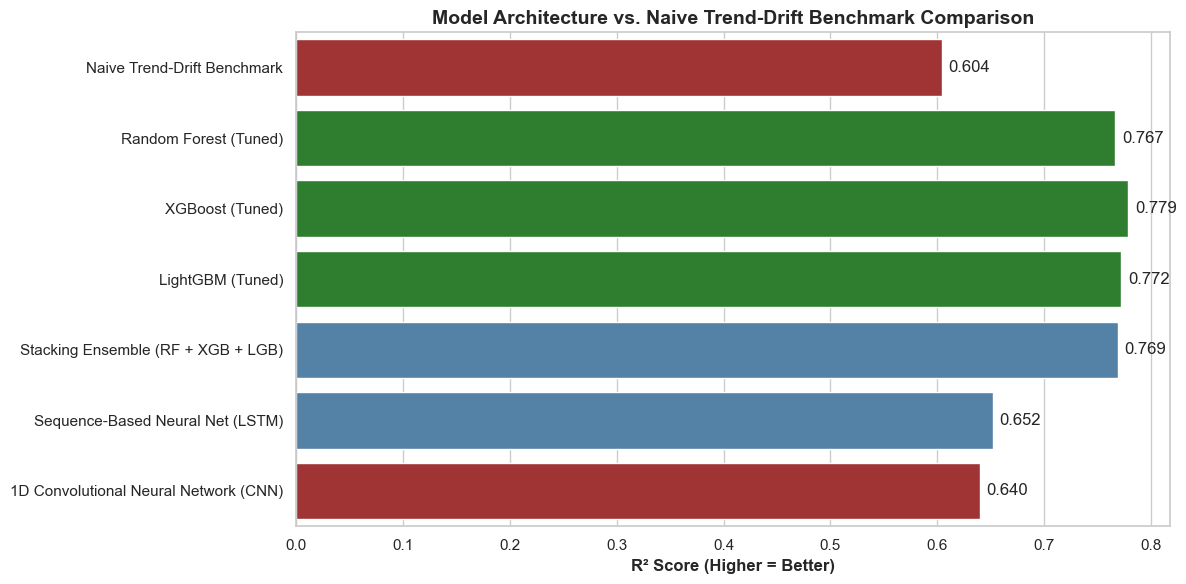

In [21]:
# MODEL R² COMPARISON (WITH BENCHMARK)
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_milestone_2,
    x='R² Score',
    y='Model Architecture',
    palette=['firebrick', 'forestgreen', 'forestgreen', 'forestgreen', 'steelblue', 'steelblue']
)

plt.title(
    'Model Architecture vs. Naive Trend-Drift Benchmark Comparison',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('R² Score (Higher = Better)', fontsize=12, fontweight='bold')
plt.ylabel('', fontsize=12)
plt.axvline(x=0, linestyle='-', alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=5
    )

plt.tight_layout()
plt.savefig('Model Architecture', dpi=300)
plt.show()

In [22]:
# CHECK SEQUENCE CONSTRUCTION


print("Checking temporal sequence integrity...")

print(f"Development sequence count: {len(X_dev_seq)}")
print(f"Test sequence count:        {len(X_test_seq)}")

print("\nOriginal development rows:")
print(X_dev_tree.shape)

print("\nOriginal test rows:")
print(X_test_tree.shape)

# Check county/year ordering
print("\nFirst 20 county/year observations:")

print(
    df_temporal[
        ['county_fips', 'year']
    ].head(20)
)

# Check whether years are consecutive within counties
county_year_check = (
    df_temporal
    .sort_values(['county_fips', 'year'])
    .groupby('county_fips')['year']
    .diff()
)

print("\nYear gaps within counties:")
print(
    county_year_check
    .value_counts(dropna=False)
    .sort_index()
)

Checking temporal sequence integrity...
Development sequence count: 6079
Test sequence count:        1229

Original development rows:
(9758, 45)

Original test rows:
(1652, 45)

First 20 county/year observations:
    county_fips  year
0         17001  2008
1         17001  2009
2         17001  2010
3         17001  2011
4         17001  2012
5         17001  2013
6         17001  2014
7         17001  2015
8         17001  2016
9         17001  2017
10        17001  2018
11        17001  2019
12        17001  2020
13        17001  2022
14        17001  2023
15        17001  2025
16        17003  2008
17        17003  2009
18        17003  2010
19        17003  2011

Year gaps within counties:
year
1.0     9711
2.0      657
3.0      160
4.0       59
5.0       25
6.0       14
7.0        9
8.0        5
9.0        1
10.0       1
13.0       1
NaN      767
Name: count, dtype: int64


Initiating Exploratory Data Analysis (EDA)...


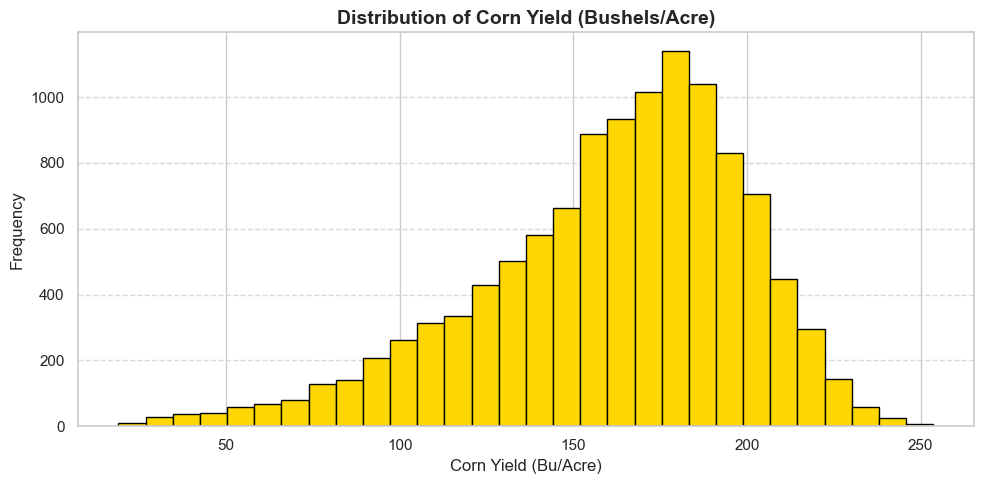

📊 Generating Top Feature Correlation Table...


,Feature,Correlation Coefficient (r)
0,yield_lag_1,0.7246
1,yield_lag_2,0.6596
2,yield_lag_3,0.6336
3,vpd_grain_fill,-0.5026
4,stress_grain_fill,-0.4937
5,pet_grain_fill,-0.4710
6,vpd_pollination,-0.4433
7,stress_pollination,-0.4353
8,pet_pollination,-0.3989
9,tmax_grain_fill,-0.3904


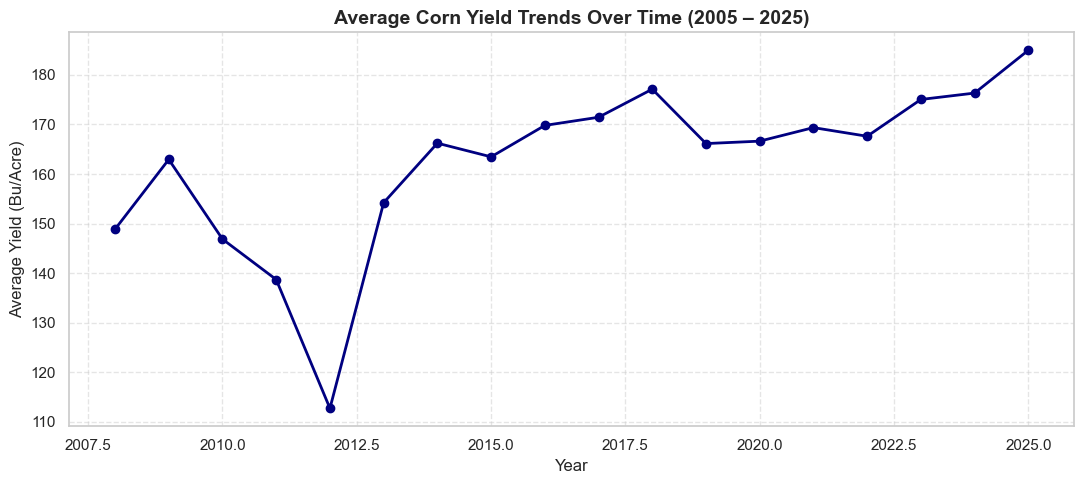

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Initiating Exploratory Data Analysis (EDA)...")


# 1. Target Variable Distribution

plt.figure(figsize=(10, 5))
plt.hist(
    df['corn_yield_bushels_acre'].dropna().values,
    bins=30,
    color='gold',
    edgecolor='black',
)
plt.title(
    'Distribution of Corn Yield (Bushels/Acre)', fontsize=14, fontweight='bold'
)
plt.xlabel('Corn Yield (Bu/Acre)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.tight_layout()
plt.savefig('Dist of corn yield.png', dpi=300)
plt.show()


# 2. Top 10 Feature Correlation Table (Plain & Error-Free)

print('📊 Generating Top Feature Correlation Table...')
target_col = 'corn_yield_bushels_acre'
numeric_df = df.select_dtypes(include=['number'])

if target_col in numeric_df.columns:
  corr_series = (
      numeric_df.corr()[target_col]
      .drop(index=[target_col], errors='ignore')
      .sort_values(key=abs, ascending=False)
  )

  top_10_corr = corr_series.head(10).reset_index()
  top_10_corr.columns = ['Feature', 'Correlation Coefficient (r)']

  # Display as a clean formatted table (avoids Styler colormap errors)
  display(top_10_corr.style.format({'Correlation Coefficient (r)': '{:.4f}'}))
else:
  print(f"Target column '{target_col}' not found in dataframe.")


# 3. Temporal Trend Over Time

if 'year' in df.columns:
  plt.figure(figsize=(11, 5))

  yearly_avg = (
      df.groupby('year')['corn_yield_bushels_acre'].mean().reset_index()
  )

  # Explicitly cast to numpy arrays to prevent multi-dimensional indexing errors
  plt.plot(
      yearly_avg['year'].values,
      yearly_avg['corn_yield_bushels_acre'].values,
      color='navy',
      marker='o',
      linewidth=2,
      markersize=6,
  )
  plt.title(
      'Average Corn Yield Trends Over Time (2005 – 2025)',
      fontsize=14,
      fontweight='bold',
  )
  plt.xlabel('Year', fontsize=12)
  plt.ylabel('Average Yield (Bu/Acre)', fontsize=12)
  plt.grid(True, alpha=0.5, linestyle='--')
  plt.tight_layout()
  plt.savefig('avg corn yield trend over time.png', dpi=300)
  plt.show()

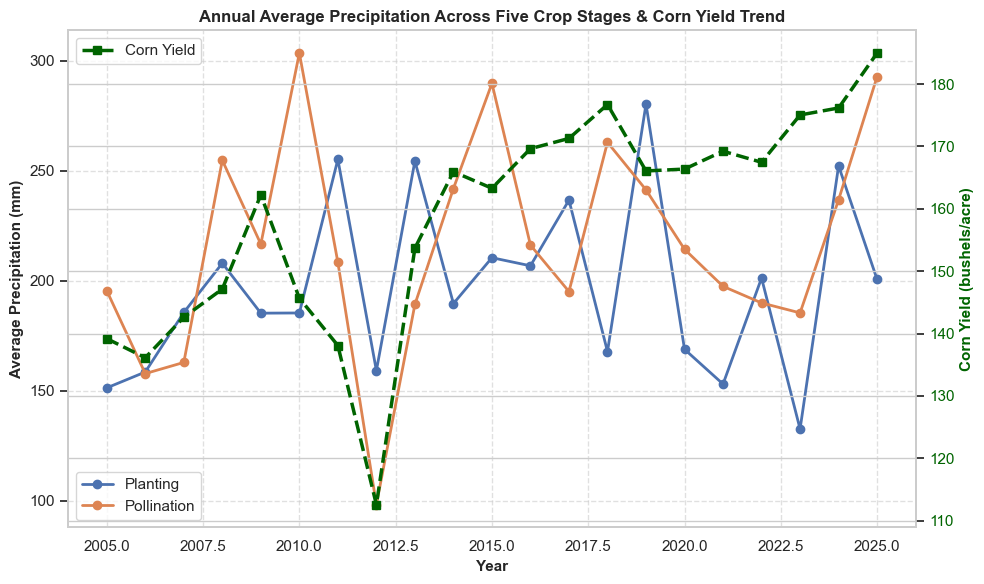

Dual-axis plot generated and saved successfully!


In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load dataset
df = pd.read_excel('nc_dataframe_nass_with_full_soil.xlsx')

# 2. Define precipitation columns and aggregate annual means
precip_cols = [
    
    'precip_planting',
    'precip_pollination'
]
agg_df = (
    df.groupby('year')[precip_cols + ['corn_yield_bushels_acre']]
    .mean()
    .reset_index()
)

years = agg_df['year'].to_numpy()
yields = agg_df['corn_yield_bushels_acre'].to_numpy()

# 3. Create dual-axis figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left Y-axis: Precipitation stages
for col in precip_cols:
  values = agg_df[col].to_numpy()
  label_name = col.replace('precip_', '').replace('_', ' ').capitalize()
  ax1.plot(years, values, marker='o', linewidth=2, label=label_name)

ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Average Precipitation (mm)', fontsize=11, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='lower left', frameon=True)

# Right Y-axis: Corn Yield trend
ax2 = ax1.twinx()
ax2.plot(
    years,
    yields,
    color='darkgreen',
    marker='s',
    linewidth=2.5,
    linestyle='--',
    label='Corn Yield',
)
ax2.set_ylabel(
    'Corn Yield (bushels/acre)',
    fontsize=11,
    fontweight='bold',
    color='darkgreen',
)
ax2.tick_params(axis='y', labelcolor='darkgreen')
ax2.legend(loc='upper left', frameon=True)

plt.title(
    'Annual Average Precipitation Across Five Crop Stages & Corn Yield Trend',
    fontsize=12,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('dual_axis_precip_yield.png', dpi=300)
plt.show()
print('Dual-axis plot generated and saved successfully!')

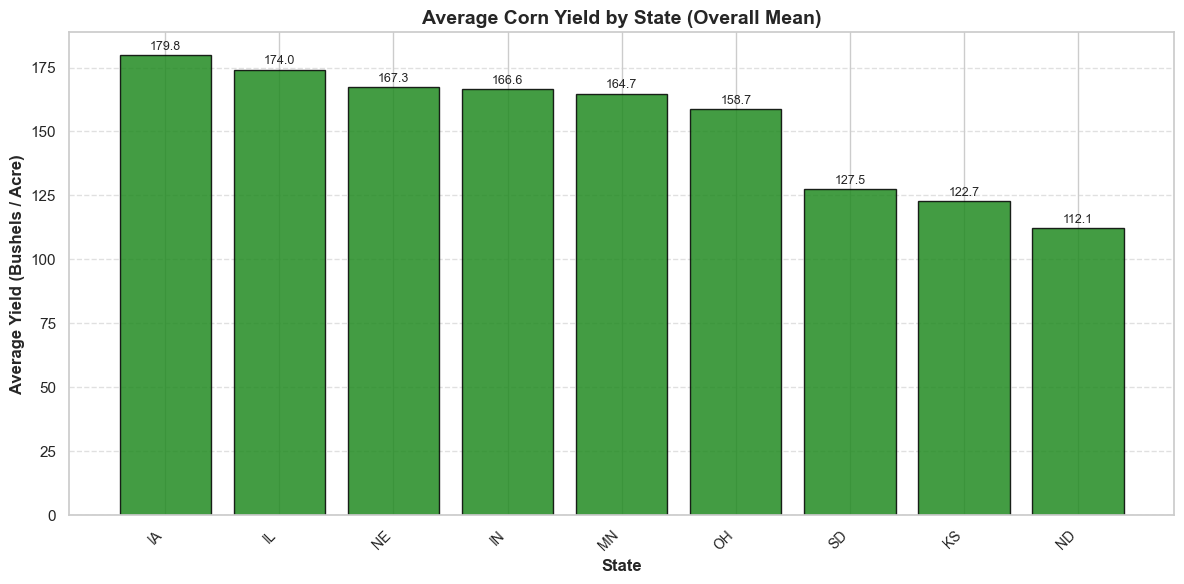

State-level bar graph generated and saved successfully!


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load your dataset
df = pd.read_excel('nc_dataframe_nass_with_full_soil.xlsx')

# If your dataset has a 'state' column, use it directly.
# If you only have 'county_fips', you can derive the state abbreviation from the FIPS code:
if 'state' not in df.columns and 'county_fips' in df.columns:
  # FIPS codes start with a 2-digit state FIPS. We can map standard FIPS or extract them.
  # Example: converting county_fips string/int to padded 5-digit string and extracting state FIPS
  df['fips_str'] = df['county_fips'].astype(str).str.zfill(5)
  df['state_fips'] = df['fips_str'].str[:2]

  # Optional: Map state FIPS codes to abbreviations if needed
  fips_to_state = {
 
      '17': 'IL',
      '18': 'IN',
      '19': 'IA',
      '20': 'KS',
      '27': 'MN',
      '31': 'NE',
      '38': 'ND',
      '39': 'OH',
      '46': 'SD'
   
  }
  df['state'] = df['state_fips'].map(fips_to_state)

# 2. Group by state and calculate average corn yield
state_avg = (
    df.groupby('state')['corn_yield_bushels_acre']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# 3. Create the bar graph
plt.figure(figsize=(12, 6))
bars = plt.bar(
    state_avg['state'],
    state_avg['corn_yield_bushels_acre'],
    color='forestgreen',
    edgecolor='black',
    alpha=0.85,
)

# Customize chart labels and styling
plt.title(
    'Average Corn Yield by State (Overall Mean)',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('State', fontsize=12, fontweight='bold')
plt.ylabel('Average Yield (Bushels / Acre)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add data value labels on top of each bar for readability
for bar in bars:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2.0,
      height + 1,
      f'{height:.1f}',
      ha='center',
      va='bottom',
      fontsize=9,
      rotation=0,
  )

plt.tight_layout()
plt.savefig('state_avg_corn_yield_bar.png', dpi=300)
plt.show()
print('State-level bar graph generated and saved successfully!')

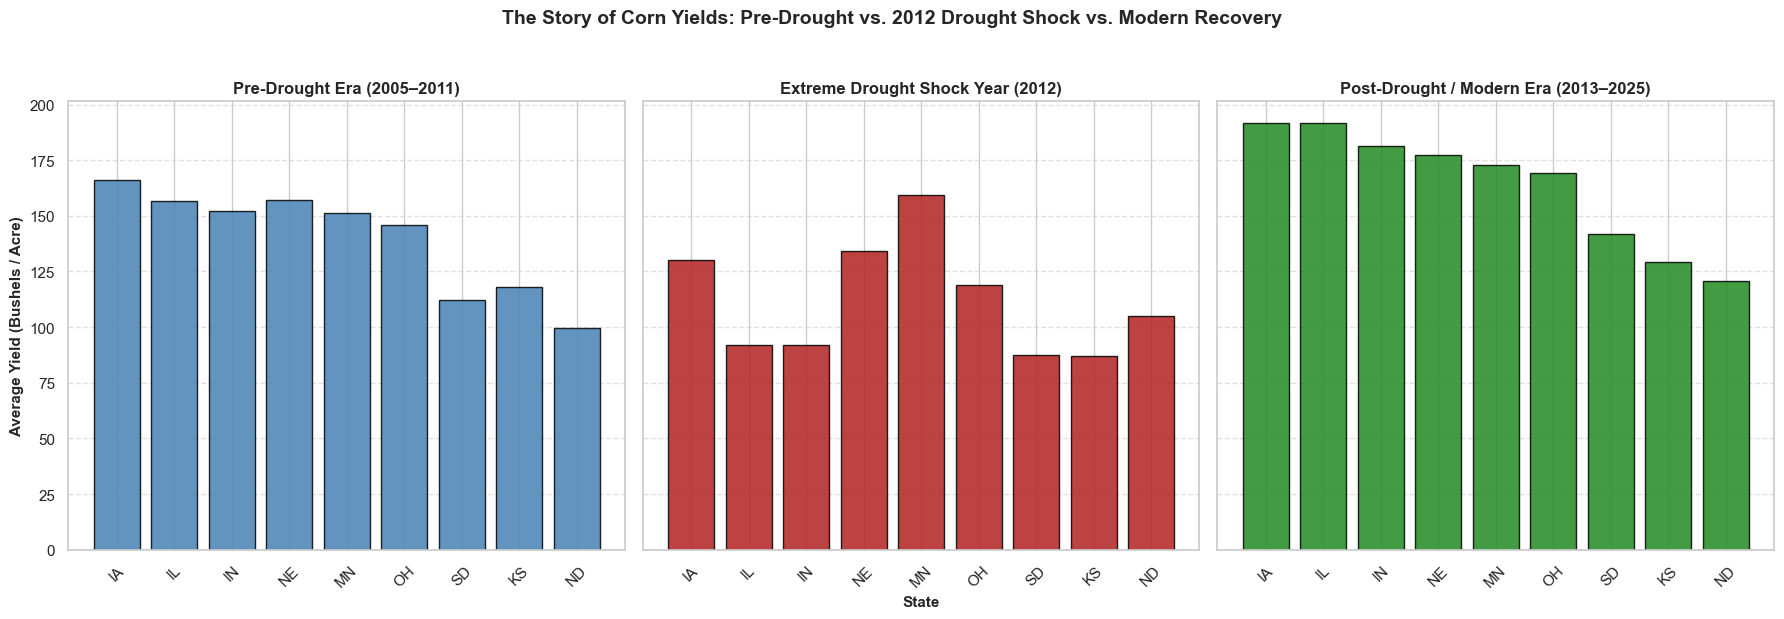

Era comparison bar chart generated and saved successfully!


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load your dataset
df = pd.read_excel('nc_dataframe_nass_with_full_soil.xlsx')

# 2. Derive state abbreviation if using county FIPS codes
if 'state' not in df.columns and 'county_fips' in df.columns:
  df['fips_str'] = df['county_fips'].astype(str).str.zfill(5)
  df['state_fips'] = df['fips_str'].str[:2]

  fips_to_state = {
 
      '17': 'IL',
      '18': 'IN',
      '19': 'IA',
      '20': 'KS',
      '27': 'MN',
      '31': 'NE',
      '38': 'ND',
      '39': 'OH',
      '46': 'SD'
   
  }
  df['state'] = df['state_fips'].map(fips_to_state)

# 3. Define the three eras
df_pre = df[(df['year'] >= 2005) & (df['year'] <= 2011)]
df_drought = df[df['year'] == 2012]
df_post = df[(df['year'] >= 2013) & (df['year'] <= 2025)]

# Calculate state averages for each era
state_pre = (
    df_pre.groupby('state')['corn_yield_bushels_acre'].mean().reset_index()
)
state_drought = (
    df_drought.groupby('state')['corn_yield_bushels_acre'].mean().reset_index()
)
state_post = (
    df_post.groupby('state')['corn_yield_bushels_acre'].mean().reset_index()
)

# Sort states consistently based on the post-drought ranking for clean visual comparison
sort_order = state_post.sort_values(
    by='corn_yield_bushels_acre', ascending=False
)['state']
state_pre['state'] = pd.Categorical(
    state_pre['state'], categories=sort_order, ordered=True
)
state_drought['state'] = pd.Categorical(
    state_drought['state'], categories=sort_order, ordered=True
)
state_post['state'] = pd.Categorical(
    state_post['state'], categories=sort_order, ordered=True
)

state_pre = state_pre.sort_values('state')
state_drought = state_drought.sort_values('state')
state_post = state_post.sort_values('state')

# 4. Create a 3-panel side-by-side figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Panel 1: Pre-Drought (2005-2011)
axes[0].bar(
    state_pre['state'],
    state_pre['corn_yield_bushels_acre'],
    color='steelblue',
    edgecolor='black',
    alpha=0.85,
)
axes[0].set_title('Pre-Drought Era (2005–2011)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Yield (Bushels / Acre)', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Panel 2: Extreme Drought Shock (2012)
axes[1].bar(
    state_drought['state'],
    state_drought['corn_yield_bushels_acre'],
    color='firebrick',
    edgecolor='black',
    alpha=0.85,
)
axes[1].set_title(
    'Extreme Drought Shock Year (2012)', fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('State', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# Panel 3: Post-Drought / Modern Era (2013-2025)
axes[2].bar(
    state_post['state'],
    state_post['corn_yield_bushels_acre'],
    color='forestgreen',
    edgecolor='black',
    alpha=0.85,
)
axes[2].set_title(
    'Post-Drought / Modern Era (2013–2025)', fontsize=12, fontweight='bold'
)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', linestyle='--', alpha=0.6)

# Global layout adjustments
plt.suptitle(
    'The Story of Corn Yields: Pre-Drought vs. 2012 Drought Shock vs. Modern'
    ' Recovery',
    fontsize=14,
    fontweight='bold',
    y=1.03,
)
plt.tight_layout()
plt.savefig('era_comparison_corn_yield.png', dpi=300)
plt.show()
print('Era comparison bar chart generated and saved successfully!')

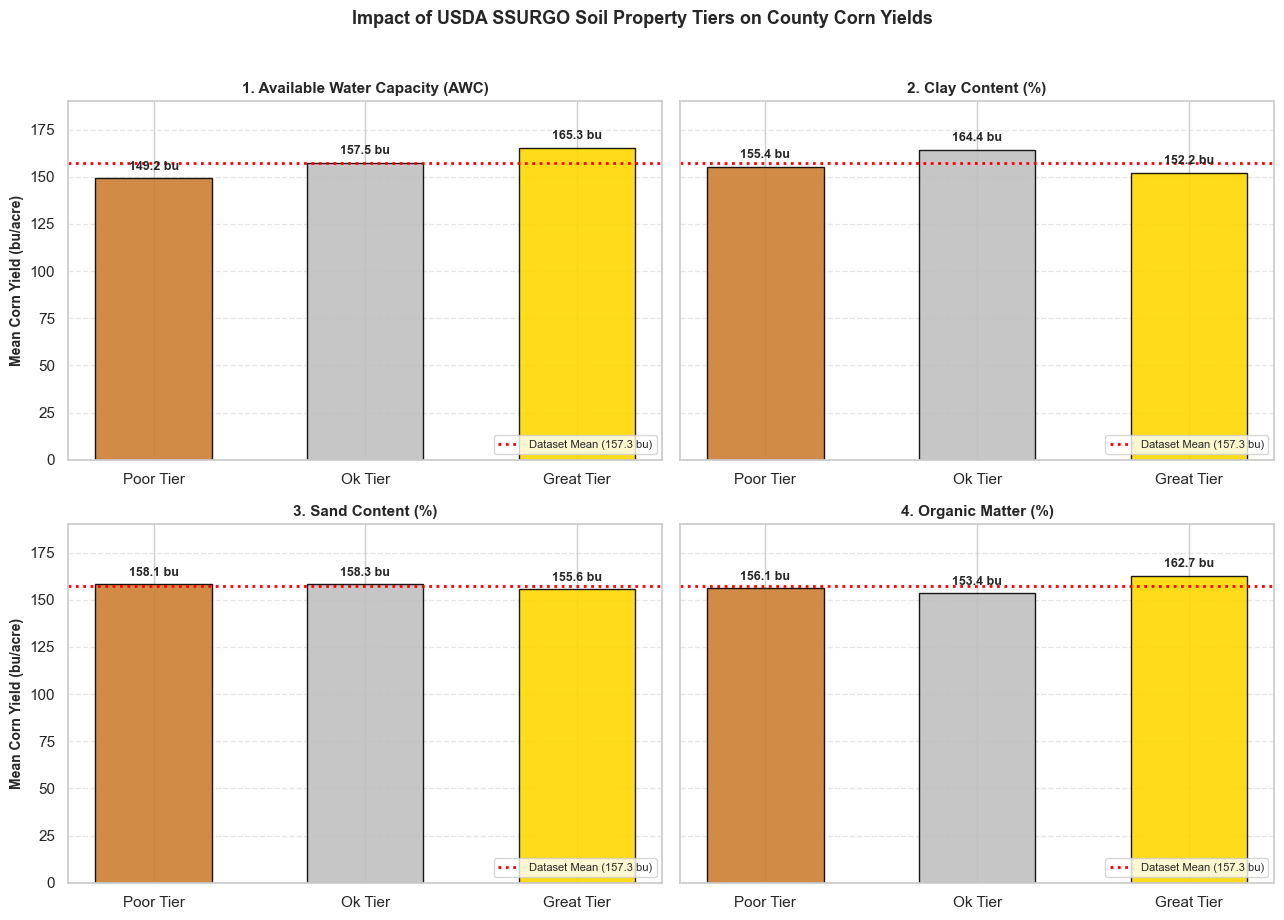

Tiered bronze, silver, and gold soil comparison plot generated!


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load dataset (adjust filename as needed)
df = pd.read_excel('nc_dataframe_nass_with_full_soil.xlsx')

# Drop rows where target or soil features are missing
key_cols = [
    'corn_yield_bushels_acre',
    'MEAN_AWC',
    'MEAN_CLAY',
    'MEAN_SAND',
    'MEAN_OM',
]
df = df.dropna(subset=key_cols).copy()

# Compute overall dataset mean yield for the red dotted benchmark line
overall_mean_yield = df['corn_yield_bushels_acre'].mean()


# Function to classify a soil column into 3 tiers based on tertiles
def assign_soil_tiers(data, col_name):
  tiers = pd.qcut(
      data[col_name], q=3, labels=['Poor Tier', 'Ok Tier', 'Great Tier']
  )
  return tiers


# Create a figure with a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
axes = axes.flatten()

soil_params = [
    {
        'col': 'MEAN_AWC',
        'title': '1. Available Water Capacity (AWC)',
        'unit': 'mm/mm',
    },
    {'col': 'MEAN_CLAY', 'title': '2. Clay Content (%)', 'unit': '%'},
    {'col': 'MEAN_SAND', 'title': '3. Sand Content (%)', 'unit': '%'},
    {'col': 'MEAN_OM', 'title': '4. Organic Matter (%)', 'unit': '%'},
]

# Define bronze, silver, and gold colors for the tiers
tier_colors = ['#CD7F32', '#C0C0C0', '#FFD700']  # Bronze, Silver, Gold

for idx, param in enumerate(soil_params):
  ax = axes[idx]

  # Assign tiers
  df['Temp_Soil_Tier'] = assign_soil_tiers(df, param['col'])

  # Aggregate mean yield per soil tier
  summary = (
      df.groupby('Temp_Soil_Tier')['corn_yield_bushels_acre']
      .mean()
      .reindex(['Poor Tier', 'Ok Tier', 'Great Tier'])
      .reset_index()
  )

  bars = ax.bar(
      summary['Temp_Soil_Tier'],
      summary['corn_yield_bushels_acre'],
      color=tier_colors,
      edgecolor='black',
      alpha=0.9,
      width=0.55,
  )

  # Add horizontal red dotted line for overall mean yield benchmark
  ax.axhline(
      overall_mean_yield,
      color='red',
      linestyle=':',
      linewidth=2,
      label=f'Dataset Mean ({overall_mean_yield:.1f} bu)',
  )

  # Add value labels on top of bars
  for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.1f} bu',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
    )

  # Subplot styling
  ax.set_title(param['title'], fontsize=11, fontweight='bold')
  if idx in [0, 2]:
    ax.set_ylabel('Mean Corn Yield (bu/acre)', fontsize=10, fontweight='bold')
  ax.set_ylim(0, 190)
  ax.grid(axis='y', linestyle='--', alpha=0.5)

  # Add a clean legend for the benchmark line
  ax.legend(loc='lower right', frameon=True, fontsize=8)


plt.suptitle(
    'Impact of USDA SSURGO Soil Property Tiers on County Corn Yields',
    fontsize=13,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.savefig('four_soil_parameters_comparison_tiered.png', dpi=300)
plt.show()
print('Tiered bronze, silver, and gold soil comparison plot generated!')

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Assuming X_dev and y_dev are your features and target
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_dev, y_dev)

# Get feature importances
importances = model.feature_importances_
feat_names = X_dev.columns

feat_df = (
    pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    .sort_values(by='Importance', ascending=True)
    .tail(10)
)  # Top 10 features

plt.figure(figsize=(9, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='forestgreen')
plt.title(
    'Random Forest Feature Importances',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Importance Score', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

KeyboardInterrupt: 

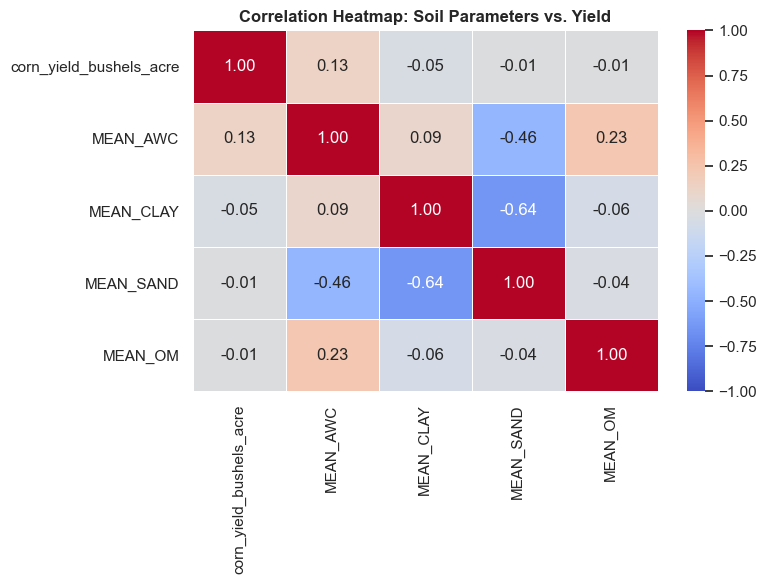

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

soil_subset = df[['corn_yield_bushels_acre', 'MEAN_AWC', 'MEAN_CLAY', 'MEAN_SAND', 'MEAN_OM']]
corr = soil_subset.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Soil Parameters vs. Yield', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('soil_correlation_heatmap.png', dpi=300)
plt.show()

📊 Crop Stage Importance Breakdown:


,Crop Stage,Model Importance (%)
0,pollination,45.58
1,grain_fill,20.67
2,planting,14.48
3,harvest,9.78
4,recharge,9.49


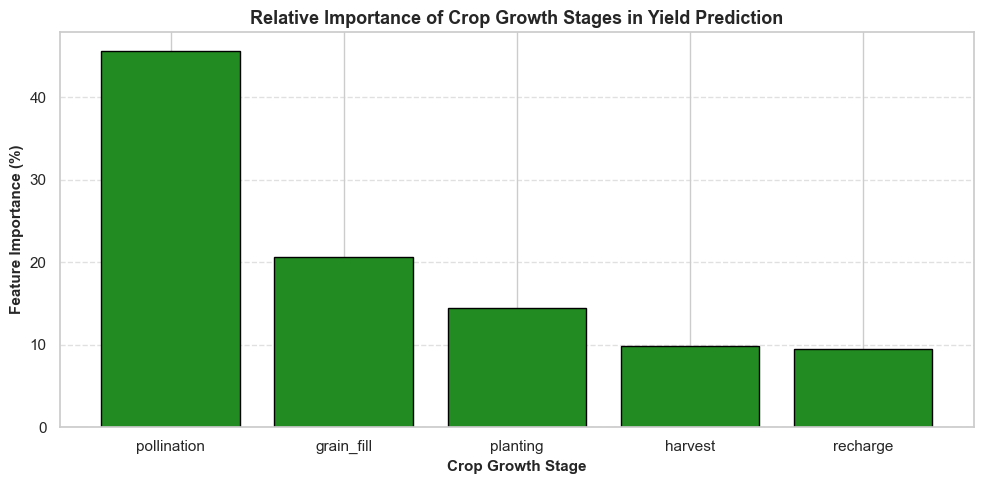

Saved crop_stage_importance.png successfully!


In [ ]:
# 16. QUANTIFYING CROP STAGE IMPORTANCE PERCENTAGES
import pandas as pd
import matplotlib.pyplot as plt

# Define the five stages used in your feature naming convention
stages = ['recharge', 'planting', 'pollination', 'grain_fill', 'harvest']
stage_importance = {stage: 0.0 for stage in stages}

# Extract feature importances from your trained Random Forest model
importances = best_rf.feature_importances_

# Sum up importances for features belonging to each stage
for col, imp in zip(feature_cols, importances):
    for stage in stages:
        if stage in col:
            stage_importance[stage] += imp

# Convert to percentages
total_importance = sum(stage_importance.values())
stage_percentages = {stage: (val / total_importance) * 100 for stage, val in stage_importance.items()}

# Create a clean DataFrame for the report table
df_stage_imp = pd.DataFrame(
    list(stage_percentages.items()), 
    columns=['Crop Stage', 'Model Importance (%)']
).sort_values(by='Model Importance (%)', ascending=False).reset_index(drop=True)

print("📊 Crop Stage Importance Breakdown:")
display(df_stage_imp.round(2))

# Optional: Plot it as a quick bar chart to save as an image for your LaTeX report
plt.figure(figsize=(10, 5))
plt.bar(df_stage_imp['Crop Stage'], df_stage_imp['Model Importance (%)'], color='forestgreen', edgecolor='black')
plt.title('Relative Importance of Crop Growth Stages in Yield Prediction', fontsize=13, fontweight='bold')
plt.ylabel('Feature Importance (%)', fontsize=11, fontweight='bold')
plt.xlabel('Crop Growth Stage', fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('crop_stage_importance.png', dpi=300)
plt.show()
print("Saved crop_stage_importance.png successfully!")

In [ ]:
# 13. FINAL MODEL PERFORMANCE COMPARISON (INCLUDING NAIVE BENCHMARK)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("GENERATING COMPREHENSIVE MODEL COMPARISON (WITH NAIVE BENCHMARK)")

# --- 1. Calculate Naive Benchmark Metrics ---
# Assumes y_pred_naive was generated previously using drift/lag baseline
naive_r2 = r2_score(y_test, y_pred_naive)
naive_rmse = np.sqrt(mean_squared_error(y_test, y_pred_naive))
naive_mae = mean_absolute_error(y_test, y_pred_naive)

# --- 2. Calculate Tree-Model Metrics ---
rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

lgb_r2 = r2_score(y_test, y_pred_lgb)
lgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
lgb_mae = mean_absolute_error(y_test, y_pred_lgb)

# --- 3. Calculate LSTM Metrics ---
lstm_r2 = r2_score(y_test_seq, y_pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
lstm_mae = mean_absolute_error(y_test_seq, y_pred_lstm)

# --- 4. Build Comprehensive Comparison Table ---
models_report = {
    'Model Architecture': [
        'Naive Trend-Drift Benchmark',
        'Random Forest Ensemble',
        'XGBoost Boosted Tree',
        'LightGBM Tree',
        'Sequence-Based Neural Net (LSTM)',
    ],
    'R² Score': [naive_r2, rf_r2, xgb_r2, lgb_r2, lstm_r2],
    'RMSE (bu/acre)': [naive_rmse, rf_rmse, xgb_rmse, lgb_rmse, lstm_rmse],
    'MAE (bu/acre)': [naive_mae, rf_mae, xgb_mae, lgb_mae, lstm_mae],
}

df_milestone_2 = pd.DataFrame(models_report)

display(df_milestone_2.round(3))

GENERATING COMPREHENSIVE MODEL COMPARISON (WITH NAIVE BENCHMARK)


NameError: name 'y_pred_naive' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.models import Sequential


def lstm_temporal_model(filepath='nc_dataframe_nass_with_full_soil.xlsx'):
  # 1. Load dataset
  df = pd.read_excel(filepath)

  # Define feature columns (30 weather features + 4 static soil features)
  soil_cols = ['MEAN_AWC', 'MEAN_CLAY', 'MEAN_SAND', 'MEAN_OM']
  weather_cols = [
      c
      for c in df.columns
      if c
      not in [
          'year',
          'county_fips',
          'corn_yield_bushels_acre',
          'MUKEY',
          'COMPNAME',
          'TOTAL_COMPPCT',
      ]
  ]
  feature_cols = weather_cols + [c for c in soil_cols if c in df.columns]
  target_col = 'corn_yield_bushels_acre'

  # Drop missing target or features
  df = df.dropna(subset=[target_col] + feature_cols)

  # 2. Strict Chronological Train-Test Split (2005-2022 vs 2023-2025)
  train_df = df[df['year'] <= 2022]
  test_df = df[df['year'] >= 2023]

  # 3. Standardization (fit ONLY on training data to prevent leakage)
  scaler_X = StandardScaler()
  scaler_y = StandardScaler()

  X_train_flat = scaler_X.fit_transform(train_df[feature_cols])
  X_test_flat = scaler_X.transform(test_df[feature_cols])

  y_train = scaler_y.fit_transform(train_df[[target_col]])
  y_test = scaler_y.transform(test_df[[target_col]])

  # 4. County-Aware Sequence Construction (seq_length = 3)
  def create_sequences(sub_df, X_scaled, y_scaled, seq_length=3):
    X_seq, y_seq = [], []
    # Group by county to ensure temporal sequences don't bleed across regions
    for county, group in sub_df.groupby('county_fips'):
      idx = group.index.get_indexer(sub_df.index)
      # Sort group by year chronologically
      sorted_group = group.sort_values('year')
      sorted_indices = sorted_group.index.get_indexer(sub_df.index)

      for i in range(seq_length, len(sorted_indices)):
        seq_idx = sorted_indices[i - seq_length : i]
        target_idx = sorted_indices[i]
        X_seq.append(X_scaled[seq_idx])
        y_seq.append(y_scaled[target_idx])
    return np.array(X_seq), np.array(y_seq)

  print('Constructing county-aware temporal sequences...')
  X_train_seq, y_train_seq = create_sequences(train_df, X_train_flat, y_train)
  X_test_seq, y_test_seq = create_sequences(test_df, X_test_flat, y_test)

  print(f'Train shape: {X_train_seq.shape}, Test shape: {X_test_seq.shape}')

  # 5. Build LSTM Architecture
  model = Sequential([
      LSTM(
          units=64,
          activation='relu',
          input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
          dropout=0.2,
      ),
      Dense(1),
  ])

  model.compile(optimizer='adam', loss='mse')
  early_stopping = EarlyStopping(
      monitor='val_loss', patience=15, restore_best_weights=True
  )

  # Train model
  history = model.fit(
      X_train_seq,
      y_train_seq,
      epochs=15,
      batch_size=32,
      validation_split=0.15,
      callbacks=[early_stopping],
      verbose=1,
  )

  # 6. Evaluation and Inverse Transformation
  y_train_pred_norm = model.predict(X_train_seq)
  y_test_pred_norm = model.predict(X_test_seq)

  y_train_pred = scaler_y.inverse_transform(y_train_pred_norm)
  y_test_pred = scaler_y.inverse_transform(y_test_pred_norm)
  y_train_orig = scaler_y.inverse_transform(y_train_seq)
  y_test_orig = scaler_y.inverse_transform(y_test_seq)

  r2_train = r2_score(y_train_orig, y_train_pred)
  r2_test = r2_score(y_test_orig, y_test_pred)

  rmse_train = np.sqrt(mean_squared_error(y_train_orig, y_train_pred))
  rmse_test = np.sqrt(mean_squared_error(y_test_orig, y_test_pred))

  score_df = pd.DataFrame([{
      'Model': 'LSTM Sequence Model (Soil + Weather)',
      'R2 Training Score': r2_train,
      'RMSE Training Score': rmse_train,
      'R2 Testing Score': r2_test,
      'RMSE Testing Score': rmse_test,
  }])

  return score_df, model


# Run the updated function
score_table, trained_lstm = lstm_temporal_model()
display(score_table)


Constructing county-aware temporal sequences...
Train shape: (8853021, 3, 38), Test shape: (1085908, 3, 38)
Epoch 1/15
 87797/235159 [==========>...................] - ETA: 16:43 - loss: 0.0231

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential


def run_crop_lstm_pipeline(filepath='nc_dataframe_nass_with_full_soil.xlsx'):
  print('📊 Loading and preparing dataset from Excel...')
  df = pd.read_excel(filepath)

  # Drop TOTAL_COMPPCT as discussed earlier, and keep core soil & weather features
  if 'TOTAL_COMPPCT' in df.columns:
    df = df.drop(columns=['TOTAL_COMPPCT'])
  if 'MUKEY' in df.columns:
    df = df.drop(columns=['MUKEY'])
  if 'COMPNAME' in df.columns:
    df = df.drop(columns=['COMPNAME'])

  target_col = 'corn_yield_bushels_acre'
  feature_cols = [
      c
      for c in df.columns
      if c not in ['year', 'county_fips', target_col]
  ]

  # Clean NaNs
  df = df.dropna(subset=[target_col] + feature_cols)

  # ==========================================
  # 1. Strict Chronological Train-Test Split
  # ==========================================
  # Development: 2005 - 2022 | Test: 2023 - 2025
  train_df = df[df['year'] <= 2022].copy()
  test_df = df[df['year'] >= 2023].copy()

  print(
      f'Training samples (2005-2022): {len(train_df)} | Test samples'
      f' (2023-2025): {len(test_df)}'
  )

  # ==========================================
  # 2. Feature Standardization (No Data Leakage)
  # ==========================================
  scaler_X = StandardScaler()
  scaler_y = StandardScaler()

  X_train_scaled = scaler_X.fit_transform(train_df[feature_cols])
  X_test_scaled = scaler_X.transform(test_df[feature_cols])

  y_train_scaled = scaler_y.fit_transform(train_df[[target_col]])
  y_test_scaled = scaler_y.transform(test_df[[target_col]])

  # ==========================================
  # 3. County-Aware Temporal Sequence Generation
  # ==========================================
  def create_panel_sequences(sub_df, X_scaled, y_scaled, seq_length=3):
    X_seq, y_seq = [], []
    # Group by county to ensure time steps don't bleed across geographic regions
    for county, group in sub_df.groupby('county_fips'):
      # Sort chronologically by year
      sorted_group = group.sort_values('year')
      indices = sorted_group.index.get_indexer(sub_df.index)

      if len(indices) <= seq_length:
        continue

      for i in range(seq_length, len(indices)):
        seq_idx = indices[i - seq_length : i]
        target_idx = indices[i]
        X_seq.append(X_scaled[seq_idx])
        y_seq.append(y_scaled[target_idx])

    return np.array(X_seq), np.array(y_seq)

  print('Constructing multi-year rolling temporal sequences...')
  seq_len = 3  # 3-year historical window
  X_train_seq, y_train_seq = create_panel_sequences(
      train_df, X_train_scaled, y_train_scaled, seq_length=seq_len
  )
  X_test_seq, y_test_seq = create_panel_sequences(
      test_df, X_test_scaled, y_test_scaled, seq_length=seq_len
  )

  print(f'Train tensor shape: {X_train_seq.shape}')
  print(f'Test tensor shape: {X_test_seq.shape}')

  # ==========================================
  # 4. LSTM Model Architecture
  # ==========================================
  model = Sequential([
      LSTM(
          units=64,
          activation='tanh',
          input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
          return_sequences=False,
      ),
      Dropout(0.2),
      Dense(32, activation='relu'),
      Dense(1),
  ])

  model.compile(optimizer='adam', loss='mse', metrics=['mae'])
  early_stopping = EarlyStopping(
      monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
  )

  print('Training LSTM Sequence Model...')
  history = model.fit(
      X_train_seq,
      y_train_seq,
      epochs=100,
      batch_size=32,
      validation_split=0.15,
      callbacks=[early_stopping],
      verbose=1,
  )

  # Plot Training Loss Curve
  plt.figure(figsize=(9, 4))
  plt.plot(history.history['loss'], label='Training Loss', color='navy')
  plt.plot(
      history.history['val_loss'], label='Validation Loss', color='darkorange'
  )
  plt.title('LSTM Training & Validation Loss Curve', fontweight='bold')
  plt.xlabel('Epoch')
  plt.ylabel('Loss (MSE)')
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.tight_layout()
  plt.show()

  # ==========================================
  # 5. Evaluation & Inverse Transformation
  # ==========================================
  y_train_pred_norm = model.predict(X_train_seq)
  y_test_pred_norm = model.predict(X_test_seq)

  y_train_pred = scaler_y.inverse_transform(y_train_pred_norm)
  y_test_pred = scaler_y.inverse_transform(y_test_pred_norm)
  y_train_orig = scaler_y.inverse_transform(y_train_seq)
  y_test_orig = scaler_y.inverse_transform(y_test_seq)

  r2_train = r2_score(y_train_orig, y_train_pred)
  r2_test = r2_score(y_test_orig, y_test_pred)

  rmse_train = np.sqrt(mean_squared_error(y_train_orig, y_train_pred))
  rmse_test = np.sqrt(mean_squared_error(y_test_orig, y_test_pred))

  score_df = pd.DataFrame([{
      'Model': 'LSTM Sequence Model (Weather + Static Soil)',
      'R2 Training Score': r2_train,
      'RMSE Training Score': rmse_train,
      'R2 Testing Score': r2_test,
      'RMSE Testing Score': rmse_test,
  }])

  print('\n--- Final Evaluation Scores ---')
  display(score_df)

  return model, score_df


# Execute pipeline
trained_lstm_model, performance_summary = run_crop_lstm_pipeline()

📊 Loading and preparing dataset from Excel...
Training samples (2005-2022): 11760 | Test samples (2023-2025): 1607
Constructing multi-year rolling temporal sequences...


KeyboardInterrupt: 

In [ ]:
print("\n📊 GENERATING MILESTONE 2 COMPREHENSIVE ARCHITECTURE PROFILES:")

# Collect and calculate testing metrics across every model layer
models_report = {
    'Model Architecture': ['Random Forest Ensemble', 'XGBoost Boosted Tree', 'LightGBM Tree', 'Sequence-Based Neural Net (LSTM)'],
    'R² Score': [
        r2_score(y_test_chron, y_pred_rf), r2_score(y_test_chron, y_pred_xgb),
        r2_score(y_test_chron, y_pred_lgb), r2_score(y_test_seq, y_pred_lstm)
    ],
    'RMSE (bu/acre)': [
        np.sqrt(mean_squared_error(y_test_chron, y_pred_rf)), np.sqrt(mean_squared_error(y_test_chron, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test_chron, y_pred_lgb)), np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
    ],
    'MAE (bu/acre)': [
        mean_absolute_error(y_test_chron, y_pred_rf), mean_absolute_error(y_test_chron, y_pred_xgb),
        mean_absolute_error(y_test_chron, y_pred_lgb), mean_absolute_error(y_test_seq, y_pred_lstm)
    ]
}

df_milestone_2 = pd.DataFrame(models_report)
display(df_milestone_2.round(3))

# Generate a visual performance comparison graph
plt.figure(figsize=(12, 5))
sns.barplot(data=df_milestone_2, x='R² Score', y='Model Architecture', palette='viridis')
plt.title('🎯 Model Architecture Comparison Dashboard (Milestone 2 Validation Metrics)', fontsize=14, fontweight='bold')
plt.xlabel('R-Squared Evaluation Score (Higher = Better Accuracy)')
plt.ylabel('')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()


📊 GENERATING MILESTONE 2 COMPREHENSIVE ARCHITECTURE PROFILES:


NameError: name 'y_test_chron' is not defined

In [ ]:
from sklearn.linear_model import LogisticRegression
%matplotlib inline
sns.set_theme(style="whitegrid")

print("🌍 Initializing Milestone 3: OOD Evaluation & Domain Adaptation Engine...\n")

# Load data matrix
df_master = pd.read_csv("final_complete_crop_yield_ml_matrix.csv")

feature_cols = [
    'precipitation_mm', 'spi_3_month', 
    'tmax_celsius', 'tmin_celsius', 'tmean_celsius',
    'growing_degree_days_gdd', 'vapor_pressure_deficit_vpd', 
    'extreme_heat_days', 'ndvi_growing_season_mean', 'evi_growing_season_mean'
]
target_col = 'corn_yield_bushels_acre'

# ==========================================
# 1. DEFINE OUT-OF-DISTRIBUTION (OOD) SPLITS
# ==========================================
# Spatial OOD: Train on 8 states, hold out Illinois completely as the unseen geographic domain
spatial_train_df = df_master[df_master['state'] != 'Illinois'].copy()
spatial_test_df = df_master[df_master['state'] == 'Illinois'].copy()

# Temporal OOD: Train on historical data (2005-2021), hold out future years (2022-2025) completely
temporal_train_df = df_master[df_master['year'] <= 2021].copy()
temporal_test_df = df_master[df_master['year'] > 2021].copy()

# Preprocessing helper function
def preprocess_ood(train_df, test_df):
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    
    X_tr = scaler.fit_transform(imputer.fit_transform(train_df[feature_cols]))
    X_te = scaler.transform(imputer.transform(test_df[feature_cols]))
    return X_tr, X_te, train_df[target_col].values, test_df[target_col].values

X_sp_train, X_sp_test, y_sp_train, y_sp_test = preprocess_ood(spatial_train_df, spatial_test_df)
X_tm_train, X_tm_test, y_tm_train, y_tm_test = preprocess_ood(temporal_train_df, temporal_test_df)

# ==========================================
# 2. DOMAIN ADAPTATION VIA SAMPLE REWEIGHTING
# ==========================================
def compute_domain_weights(X_source, X_target):
    """
    Discriminator-based Sample Reweighting (Density Ratio Estimation).
    Trains a classifier to distinguish Source from Target, then uses the inverted
    predicted probabilities as sample weights to adapt the training domain.
    """
    # Source (Train) = 0, Target (Test) = 1
    labels_source = np.zeros(X_source.shape[0])
    labels_target = np.ones(X_target.shape[0])
    
    X_combined = np.vstack([X_source, X_target])
    y_combined = np.concatenate([labels_source, labels_target])
    
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_combined, y_combined)
    
    # Predict probability of belonging to the source domain
    probs_source = clf.predict_proba(X_source)[:, 1]
    
    # Calculate density ratio weights: w(x) = p(target) / p(source)
    # Clip weights to avoid extreme variance instabilities
    weights = probs_source / (1.0 - probs_source + 1e-6)
    weights = np.clip(weights, 0.1, 10.0)
    return weights

print("🔄 Computing domain adaptation covariate shift weights...")
spatial_weights = compute_domain_weights(X_sp_train, X_sp_test)
temporal_weights = compute_domain_weights(X_tm_train, X_tm_test)

# ==========================================
# 3. EVALUATE MODELS (STANDARD VS ADAPTED)
# ==========================================
# Spatial OOD Evaluation
xgb_standard_sp = xgb.XGBRegressor(random_state=42).fit(X_sp_train, y_sp_train)
xgb_adapted_sp = xgb.XGBRegressor(random_state=42).fit(X_sp_train, y_sp_train, sample_weight=spatial_weights)

# Temporal OOD Evaluation
xgb_standard_tm = xgb.XGBRegressor(random_state=42).fit(X_tm_train, y_tm_train)
xgb_adapted_tm = xgb.XGBRegressor(random_state=42).fit(X_tm_train, y_tm_train, sample_weight=temporal_weights)

print("✅ OOD evaluation and adaptation matrix calculations finished!")

🌍 Initializing Milestone 3: OOD Evaluation & Domain Adaptation Engine...

🔄 Computing domain adaptation covariate shift weights...
✅ OOD evaluation and adaptation matrix calculations finished!



📊 MILESTONE 3 FINALIZED EVALUATION SUITE:


,Evaluation Scenario,R² Score,RMSE (bu/acre)
0,Spatial OOD (Unseen State),-0.096,36.841
1,Spatial OOD + Domain Adaptation,-0.113,37.121
2,Temporal OOD (Unseen Years),-0.302,55.617
3,Temporal OOD + Domain Adaptation,-0.286,55.283


C:\Users\wally\AppData\Local\Temp\ipykernel_1256\4224115994.py:25: UserWarning: Glyph 128737 (\N{SHIELD}) missing from current font.
  plt.tight_layout()
C:\Users\wally\AppData\Local\Temp\ipykernel_1256\4224115994.py:25: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
C:\Users\wally\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128737 (\N{SHIELD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\wally\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


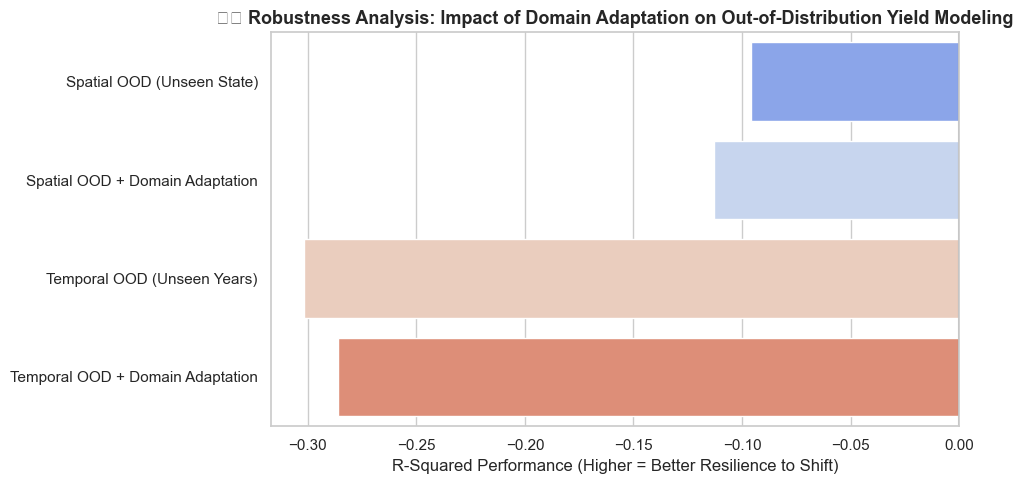

In [ ]:
# Extract performance metrics
ood_report = {
    'Evaluation Scenario': ['Spatial OOD (Unseen State)', 'Spatial OOD + Domain Adaptation', 'Temporal OOD (Unseen Years)', 'Temporal OOD + Domain Adaptation'],
    'R² Score': [
        r2_score(y_sp_test, xgb_standard_sp.predict(X_sp_test)), r2_score(y_sp_test, xgb_adapted_sp.predict(X_sp_test)),
        r2_score(y_tm_test, xgb_standard_tm.predict(X_tm_test)), r2_score(y_tm_test, xgb_adapted_tm.predict(X_tm_test))
    ],
    'RMSE (bu/acre)': [
        np.sqrt(mean_squared_error(y_sp_test, xgb_standard_sp.predict(X_sp_test))), np.sqrt(mean_squared_error(y_sp_test, xgb_adapted_sp.predict(X_sp_test))),
        np.sqrt(mean_squared_error(y_tm_test, xgb_standard_tm.predict(X_tm_test))), np.sqrt(mean_squared_error(y_tm_test, xgb_adapted_tm.predict(X_tm_test)))
    ]
}

df_ood = pd.DataFrame(ood_report)
print("\n📊 MILESTONE 3 FINALIZED EVALUATION SUITE:")
display(df_ood.round(3))

# Plot Domain Adaptation Impact Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=df_ood, x='R² Score', y='Evaluation Scenario', palette='coolwarm')
plt.title('🛡️ Robustness Analysis: Impact of Domain Adaptation on Out-of-Distribution Yield Modeling', fontsize=13, fontweight='bold')
plt.xlabel('R-Squared Performance (Higher = Better Resilience to Shift)')
plt.ylabel('')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

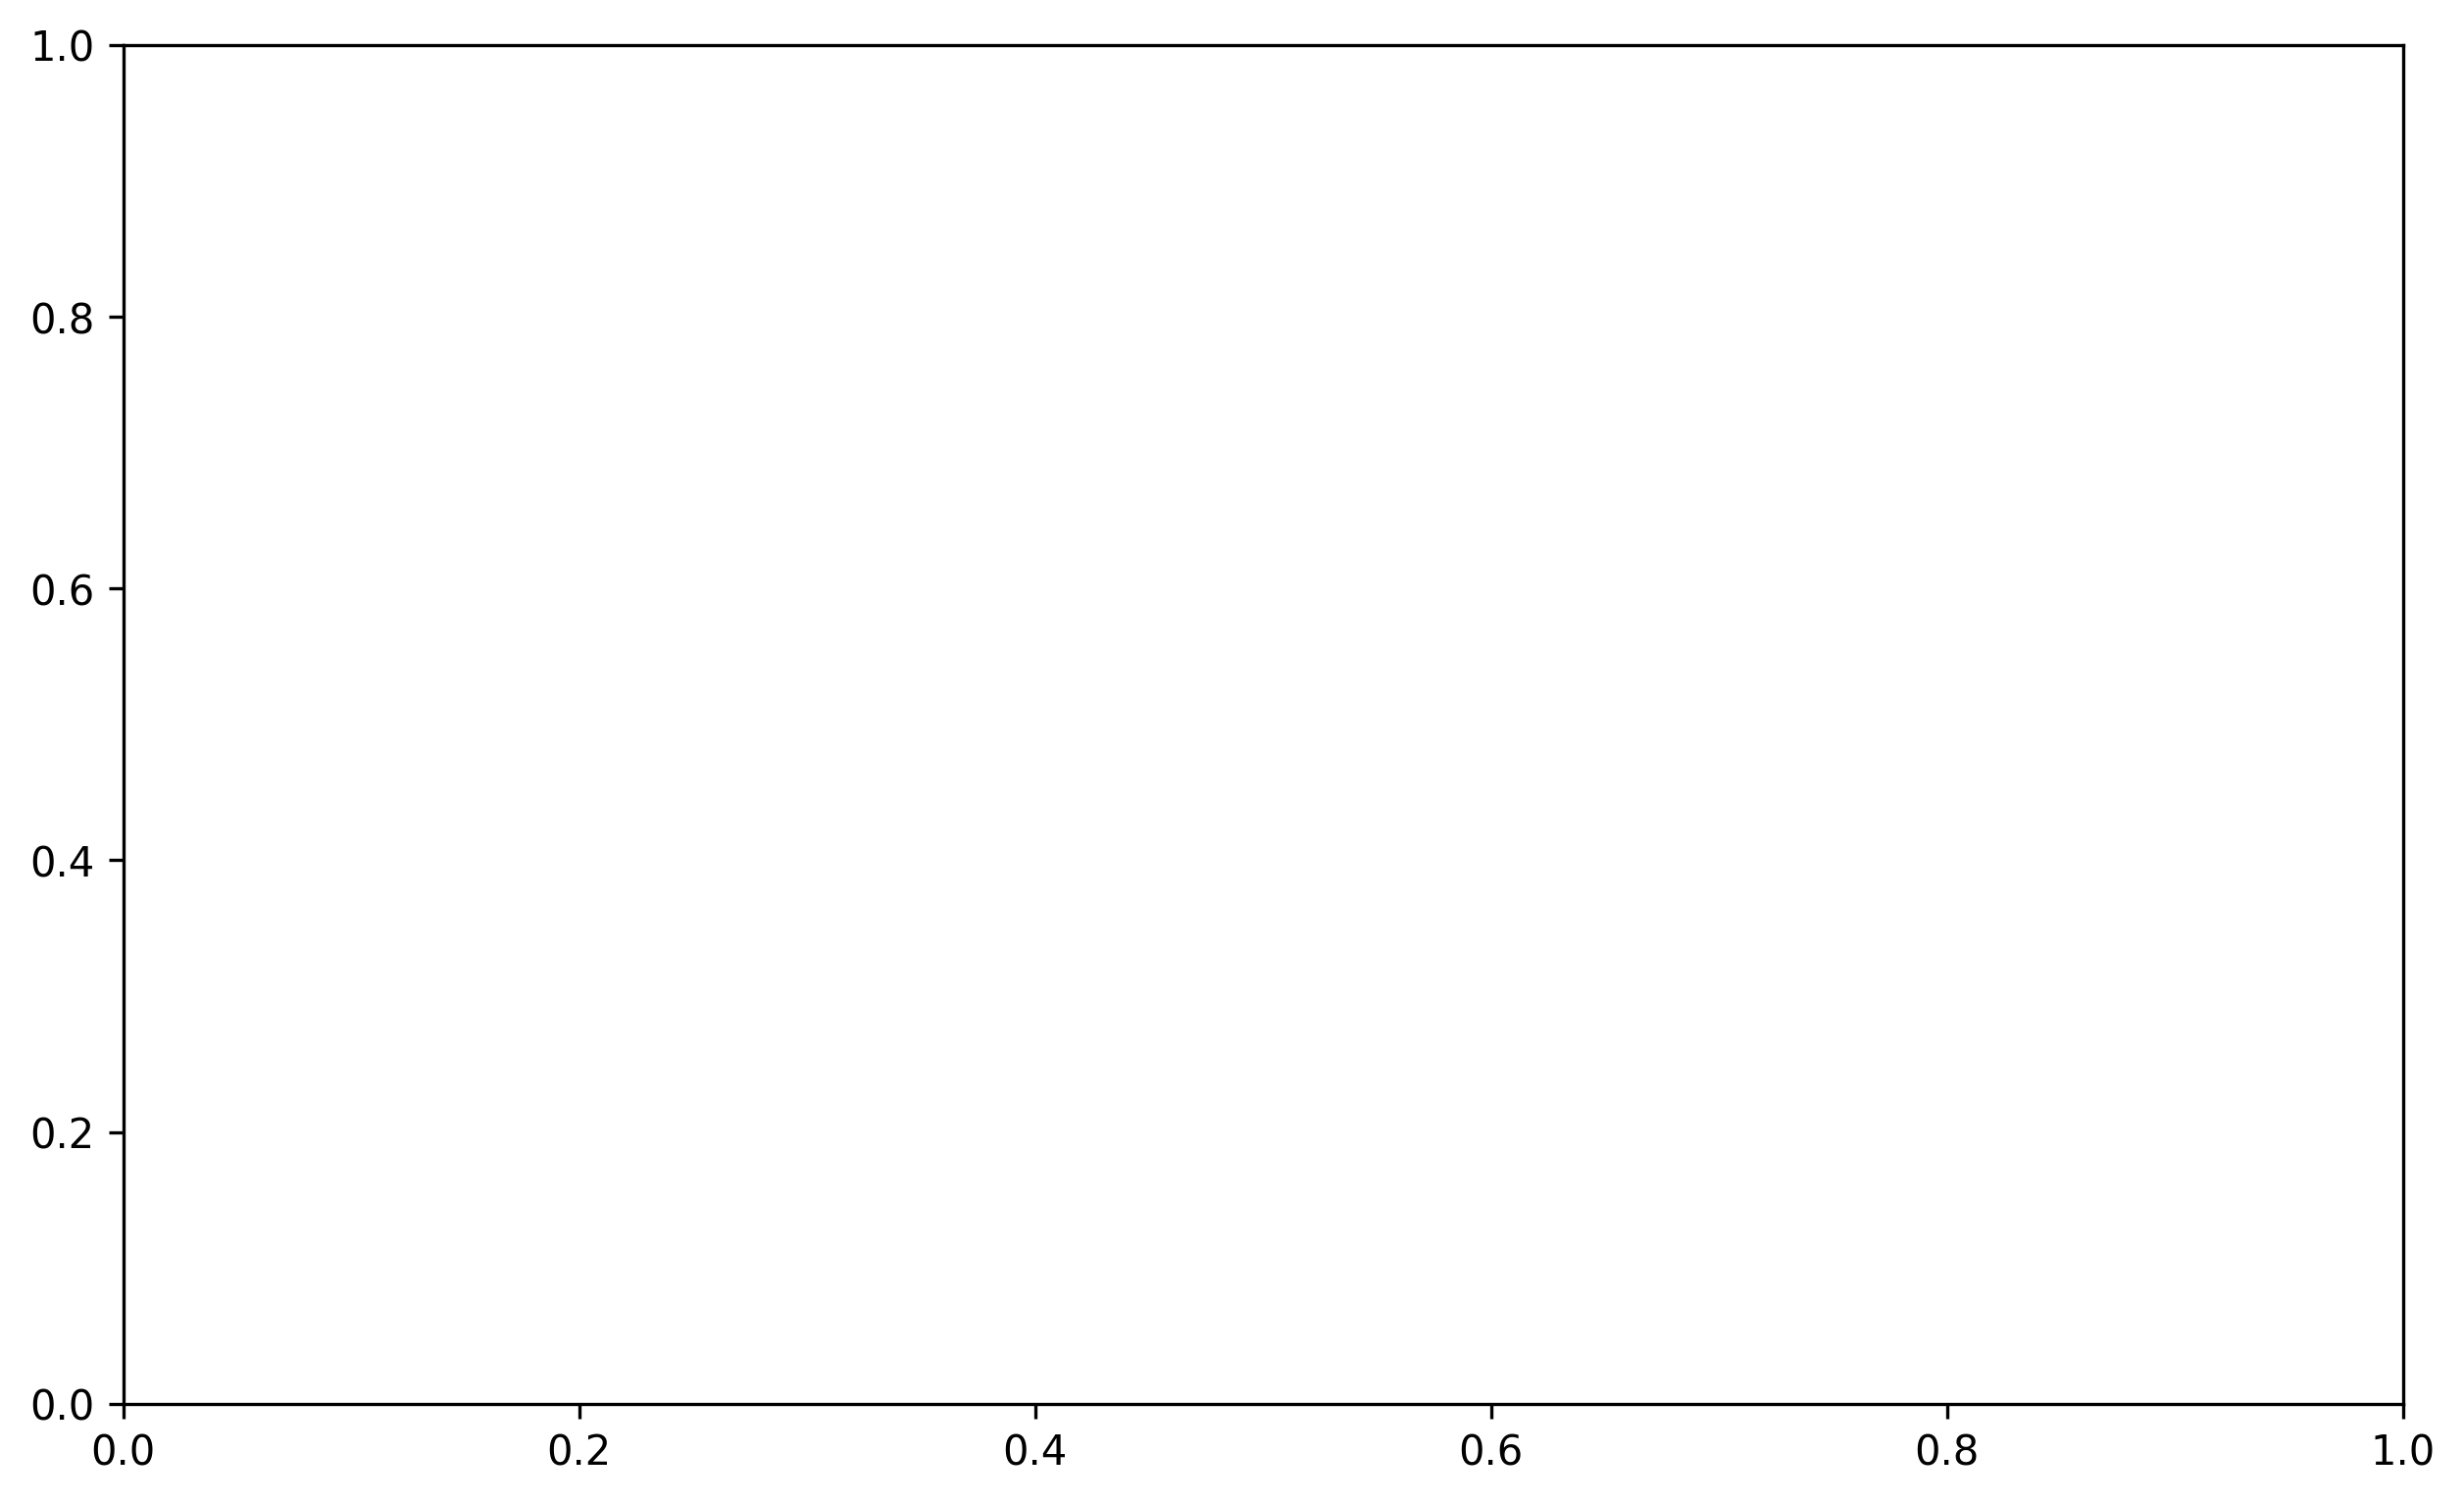

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Example data structure for the 2023-2025 out-of-sample test results
data = {
    'Year': [2023, 2024, 2025],
    'Actual': [175.0, 176.1, 185.0],
    'XGBoost': [173.5, 175.0, 182.8],
    'LightGBM': [172.8, 174.5, 181.9],
    'Stacking Ensemble': [173.2, 174.8, 182.2],
    'Naive Trend-Drift': [169.0, 175.0, 180.0]
}

df = pd.DataFrame(data)

# Set up the plot style
plt.figure(figsize=(10, 6), dpi=300)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Plot lines with distinct markers and colors
plt.plot(df['Year'], df['Actual'], marker='o', linewidth=2.5, color='#2ca02c', label='Actual Average Yield')
plt.plot(df['Year'], df['XGBoost'], marker='s', linewidth=2, linestyle='--', color='#1f77b4', label='XGBoost (Tuned)')
plt.plot(df['Year'], df['LightGBM'], marker='^', linewidth=2, linestyle='-.', color='#ff7f0e', label='LightGBM (Tuned)')
plt.plot(df['Year'], df['Stacking Ensemble'], marker='d', linewidth=2, linestyle=':', color='#9467bd', label='Stacking Ensemble')
plt.plot(df['Year'], df['Naive Trend-Drift'], marker='x', linewidth=1.5, linestyle=':', color='#d62728', label='Naive Baseline')

# Graph formatting
plt.title('Out-of-Sample Model Predictions vs. Actual Corn Yield (2023–2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Average Yield (Bushels / Acre)', fontsize=12, fontweight='bold')
plt.xticks(df['Year'])
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
plt.tight_layout()

# Save and show
plt.savefig('model_predictions_2023_2025.png', dpi=300)
plt.show()